# Option Pricing with Reinforcement Learning

### Problem: Bermudan Put Option

A Bermudan put option gives the holder the right (but not obligation) to sell an asset at strike price K at discrete exercise dates.

**Parameters:**
- S₀: Initial stock price
- K: Strike price
- T: Time to maturity
- r: Risk-free rate
- σ: Volatility
- N: Number of exercise dates

**Payoff at exercise:** max(K - S_t, 0)

**Goal:** Find optimal exercise policy to maximize expected discounted payoff

# Evaluation Framework Architecture

```
┌─────────────────────────────────────────────────────────────────────┐
│                        OPTION PRICING FRAMEWORK                      │
└─────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│  1. PATH GENERATION (Extensible)                                     │
├─────────────────────────────────────────────────────────────────────┤
│                                                                       │
│    PathGenerator (ABC)                                               │
│         ├── GBMPathGenerator                                         │
│         ├── JumpDiffusionPathGenerator                               │
│         └── HistoricalDataPathGenerator                              │
│                                                                       │
│    All environments and algorithms can use any generator             │
└─────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│  2. ENVIRONMENT                                                       │
├─────────────────────────────────────────────────────────────────────┤
│                                                                       │
│    BermudanPutEnv(params, generator, seed)                           │
│         - Accepts any PathGenerator                                  │
│         - Pre-generates full path at reset()                         │
│         - Gym-style interface for RL training                        │
│                                                                       │
└─────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│  3. PRICING METHODS (Trained independently)                          │
├─────────────────────────────────────────────────────────────────────┤
│                                                                       │
│    ┌─────────────────┐    ┌─────────────────┐    ┌─────────────────┐│
│    │   LSM Algorithm │    │  Q-Learning     │    │      DQN        ││
│    │                 │    │                 │    │                 ││
│    │  - Regression   │    │  - Q-table      │    │  - Neural net   ││
│    │  - Backward     │    │  - Epsilon-     │    │  - Experience   ││
│    │    induction    │    │    greedy       │    │    replay       ││
│    │                 │    │  - Discretized  │    │  - Continuous   ││
│    └────────┬────────┘    └────────┬────────┘    └────────┬────────┘│
│             │                      │                       │         │
│             └──────────────────────┴───────────────────────┘         │
│                                    │                                 │
│                         Generate policy_fn(s, t)                     │
│                                                                       │
└─────────────────────────────────────────────────────────────────────┘

                                    │
                                    ▼

┌─────────────────────────────────────────────────────────────────────┐
│  4. EVALUATION FRAMEWORK (Fair Comparison)                           │
├─────────────────────────────────────────────────────────────────────┤
│                                                                       │
│    TestSet(params, n_paths=5000, generator, seed=999)               │
│         │                                                             │
│         ├── Generate FIXED test paths (once)                         │
│         │   - Same paths for ALL methods                             │
│         │   - Eliminates simulation noise                            │
│         │                                                             │
│         ├── evaluate_policy(policy_fn, name, time)                  │
│         │   └──> EvaluationResult                                    │
│         │        ├── method_name                                     │
│         │        ├── mean_value                                      │
│         │        ├── std_error                                       │
│         │        ├── values                                          │
│         │        ├── exercise_times                                  │
│         │        └── training_time                                   │
│         │                                                             │
│         └── evaluate_longstaff_schwartz()                           │
│             └──> EvaluationResult                                    │
│                                                                       │
└─────────────────────────────────────────────────────────────────────┘

                                    │
                                    ▼

┌─────────────────────────────────────────────────────────────────────┐
│  5. COMPARISON & VISUALIZATION                                       │
├─────────────────────────────────────────────────────────────────────┤
│                                                                       │
│    ComparisonVisualizer(results: List[EvaluationResult], params)    │
│         │                                                             │
│         ├── print_summary_table()                                   │
│         │   - Formatted comparison table                             │
│         │   - Gaps from benchmark                                    │
│         │   - All key metrics                                        │
│         │                                                             │
│         └── plot_summary()                                          │
│             ├── Price comparison (bar chart)                         │
│             ├── Exercise time distributions                          │
│             ├── Value distributions                                  │
│             ├── Training time comparison                             │
│             ├── Exercise statistics (box plots)                      │
│             └── Summary table                                        │
│                                                                       │
└─────────────────────────────────────────────────────────────────────┘


WORKFLOW EXAMPLE:
═════════════════

    1. Create test set (ONCE)
       ┌────────────────────────────────────┐
       │ test_set = TestSet(params,         │
       │   n_paths=5000, seed=999)          │
       └────────────────────────────────────┘
                      │
                      ▼
    2. Evaluate each method
       ┌────────────────────────────────────┐
       │ lsm_result = test_set              │
       │   .evaluate_longstaff_schwartz()   │
       ├────────────────────────────────────┤
       │ ql_result = test_set               │
       │   .evaluate_policy(ql_policy,      │
       │     "Q-Learning", time)            │
       ├────────────────────────────────────┤
       │ dqn_result = test_set              │
       │   .evaluate_policy(dqn_policy,     │
       │     "DQN", time)                   │
       └────────────────────────────────────┘
                      │
                      ▼
    3. Compare all methods
       ┌────────────────────────────────────┐
       │ results = [lsm_result,             │
       │            ql_result,               │
       │            dqn_result]              │
       ├────────────────────────────────────┤
       │ viz = ComparisonVisualizer(        │
       │   results, params)                 │
       ├────────────────────────────────────┤
       │ viz.print_summary_table()          │
       │ viz.plot_summary()                 │
       └────────────────────────────────────┘


KEY BENEFITS:
═════════════

✓ Same paths for all methods    → Fair comparison
✓ Organized results             → Clean code
✓ Reusable components           → DRY principle
✓ Easy to extend                → Add methods in 3 lines
✓ Comprehensive metrics         → Full analysis
✓ Production-ready              → Type-safe, documented



EXTENSIBILITY:
══════════════

Adding a new method:

    # 1. Train your agent
    my_agent = MyAgent(params)
    start = time.time()
    my_agent.train(env, n_episodes=1000)
    training_time = time.time() - start
    
    # 2. Get policy function
    my_policy = my_agent.get_policy_function()
    
    # 3. Evaluate on test set (3 lines!)
    my_result = test_set.evaluate_policy(my_policy, "My Method", training_time)
    
    # 4. Add to comparison
    all_results.append(my_result)
    viz = ComparisonVisualizer(all_results, params)
    viz.plot_summary()
    
    # Done! Your method is now fully integrated!
```


## One line summary
LSM Whoops RL's ass.

In [66]:
# Standard imports
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from typing import Tuple, List, Optional, Callable
import time
from dataclasses import dataclass

# Set random seed for reproducibility
np.random.seed(42)
import sys
import os

PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)


# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Imports successful")

Imports successful


## Single asset bermudan option with GBM

### Part 1: Problem Configuration

In [67]:
@dataclass
class OptionParams:
    """Parameters for Bermudan Put Option"""
    S0: float = 100.0        # Initial stock price
    K: float = 100.0         # Strike price
    T: float = 1.0           # Time to maturity (years)
    r: float = 0.05          # Risk-free rate
    sigma: float = 0.2       # Volatility
    N: int = 10              # Number of exercise dates (including maturity)
    
    @property
    def dt(self) -> float:
        """Time step between exercise dates"""
        return self.T / self.N
    
    @property
    def discount_factor(self) -> float:
        """Discount factor per time step"""
        return np.exp(-self.r * self.dt)
    
    def __str__(self):
        return (f"Bermudan Put: S0={self.S0}, K={self.K}, T={self.T}, "
                f"r={self.r:.2%}, σ={self.sigma:.2%}, N={self.N}")

# Create default parameters
params = OptionParams()
print(params)
print(f"Time step dt: {params.dt:.4f}")
print(f"Discount factor: {params.discount_factor:.6f}")

Bermudan Put: S0=100.0, K=100.0, T=1.0, r=5.00%, σ=20.00%, N=10
Time step dt: 0.1000
Discount factor: 0.995012


### Part 2: Stock Price Simulation (Extensible Framework)

We create an **extensible framework** for generating stock price paths. This allows us to easily switch between different models:

1. **Geometric Brownian Motion (GBM)** - Classic model
2. **Jump Diffusion** - GBM with occasional jumps (Merton model)
3. **Historical Data** - Real market data
4. **Custom processes** - Any user-defined dynamics

##### Base Interface: PathGenerator

All path generators implement a common interface, making it easy to plug in different models.

In [68]:
from abc import ABC, abstractmethod

class PathGenerator(ABC):
    """Abstract base class for stock price path generators."""
    
    @abstractmethod
    def generate_paths(self, params: OptionParams, n_paths: int, seed: Optional[int] = None) -> np.ndarray:
        """
        Generate stock price paths.
        
        Args:
            params: Option parameters
            n_paths: Number of paths to simulate
            seed: Random seed for reproducibility
        
        Returns:
            paths: Array of shape (n_paths, N+1) containing stock prices
                   paths[:, 0] = S0, paths[:, N] = final price
        """
        pass
    
    def __call__(self, params: OptionParams, n_paths: int, seed: Optional[int] = None) -> np.ndarray:
        """Allow using generator as a callable."""
        return self.generate_paths(params, n_paths, seed)


class GBMPathGenerator(PathGenerator):
    """
    Geometric Brownian Motion path generator.
    
    Model: dS_t = r * S_t * dt + sigma * S_t * dW_t
    
    Discrete form: S_{t+1} = S_t * exp((r - 0.5*sigma^2)*dt + sigma*sqrt(dt)*Z)
    where Z ~ N(0,1)
    """
    
    def generate_paths(self, params: OptionParams, n_paths: int, seed: Optional[int] = None) -> np.ndarray:
        if seed is not None:
            np.random.seed(seed)
        
        dt = params.dt
        N = params.N
        
        # Initialize paths
        paths = np.zeros((n_paths, N + 1))
        paths[:, 0] = params.S0
        
        # Generate random shocks
        Z = np.random.standard_normal((n_paths, N))
        
        # Simulate paths
        drift = (params.r - 0.5 * params.sigma**2) * dt
        diffusion = params.sigma * np.sqrt(dt)
        
        for t in range(N):
            paths[:, t + 1] = paths[:, t] * np.exp(drift + diffusion * Z[:, t])
        
        return paths


class JumpDiffusionPathGenerator(PathGenerator):
    """
    Merton Jump Diffusion model.
    
    Model: dS_t = r * S_t * dt + sigma * S_t * dW_t + S_t * dJ_t
    
    where J_t is a compound Poisson process:
    - Jumps arrive with intensity lambda (jump_intensity)
    - Jump sizes are log-normal: log(1+J) ~ N(jump_mean, jump_std)
    """
    
    def __init__(self, jump_intensity: float = 0.1, jump_mean: float = -0.05, jump_std: float = 0.1):
        """
        Args:
            jump_intensity: Average number of jumps per year
            jump_mean: Mean of log jump size
            jump_std: Std deviation of log jump size
        """
        self.jump_intensity = jump_intensity
        self.jump_mean = jump_mean
        self.jump_std = jump_std
    
    def generate_paths(self, params: OptionParams, n_paths: int, seed: Optional[int] = None) -> np.ndarray:
        if seed is not None:
            np.random.seed(seed)
        
        dt = params.dt
        N = params.N
        
        # Initialize paths
        paths = np.zeros((n_paths, N + 1))
        paths[:, 0] = params.S0
        
        # GBM component
        Z = np.random.standard_normal((n_paths, N))
        drift = (params.r - 0.5 * params.sigma**2) * dt
        diffusion = params.sigma * np.sqrt(dt)
        
        # Jump component
        jump_prob = self.jump_intensity * dt
        
        for t in range(N):
            # Continuous part (GBM)
            log_return = drift + diffusion * Z[:, t]
            
            # Jump part
            jump_occurs = np.random.uniform(0, 1, n_paths) < jump_prob
            if np.any(jump_occurs):
                jump_sizes = np.random.normal(self.jump_mean, self.jump_std, n_paths)
                log_return += jump_occurs * jump_sizes
            
            paths[:, t + 1] = paths[:, t] * np.exp(log_return)
        
        return paths


class HistoricalDataPathGenerator(PathGenerator):
    """
    Generate paths by resampling from historical data.
    
    This is useful for testing strategies on real market dynamics.
    """
    
    def __init__(self, historical_returns: np.ndarray):
        """
        Args:
            historical_returns: Array of historical log returns
        """
        self.historical_returns = historical_returns
    
    def generate_paths(self, params: OptionParams, n_paths: int, seed: Optional[int] = None) -> np.ndarray:
        if seed is not None:
            np.random.seed(seed)
        
        N = params.N
        paths = np.zeros((n_paths, N + 1))
        paths[:, 0] = params.S0
        
        # Bootstrap returns from historical data
        for t in range(N):
            sampled_returns = np.random.choice(self.historical_returns, size=n_paths, replace=True)
            paths[:, t + 1] = paths[:, t] * np.exp(sampled_returns)
        
        return paths


# Create default generator
default_generator = GBMPathGenerator()

# Convenience function (backward compatible)
def simulate_stock_paths(params: OptionParams, n_paths: int, seed: Optional[int] = None, 
                        generator: PathGenerator = None) -> np.ndarray:
    """
    Simulate stock price paths using specified generator (defaults to GBM).
    
    Args:
        params: Option parameters
        n_paths: Number of paths to simulate
        seed: Random seed for reproducibility
        generator: PathGenerator instance (defaults to GBM)
    
    Returns:
        paths: Array of shape (n_paths, N+1) containing stock prices
    """
    if generator is None:
        generator = default_generator
    return generator.generate_paths(params, n_paths, seed)

Testing Path Generators:

1. GBM Generator:
   Shape: (3, 11)
   First path: [100.         103.50140085 102.908531   107.5336654  118.76287177]

2. Jump Diffusion Generator:
   Shape: (3, 11)
   First path: [100.         103.50140085 102.908531   107.5336654  118.76287177]

3. Historical Data Generator:
   Shape: (3, 11)
   First path: [100.          95.00336897  98.00597361  94.66795454  86.4501721 ]

All generators working!


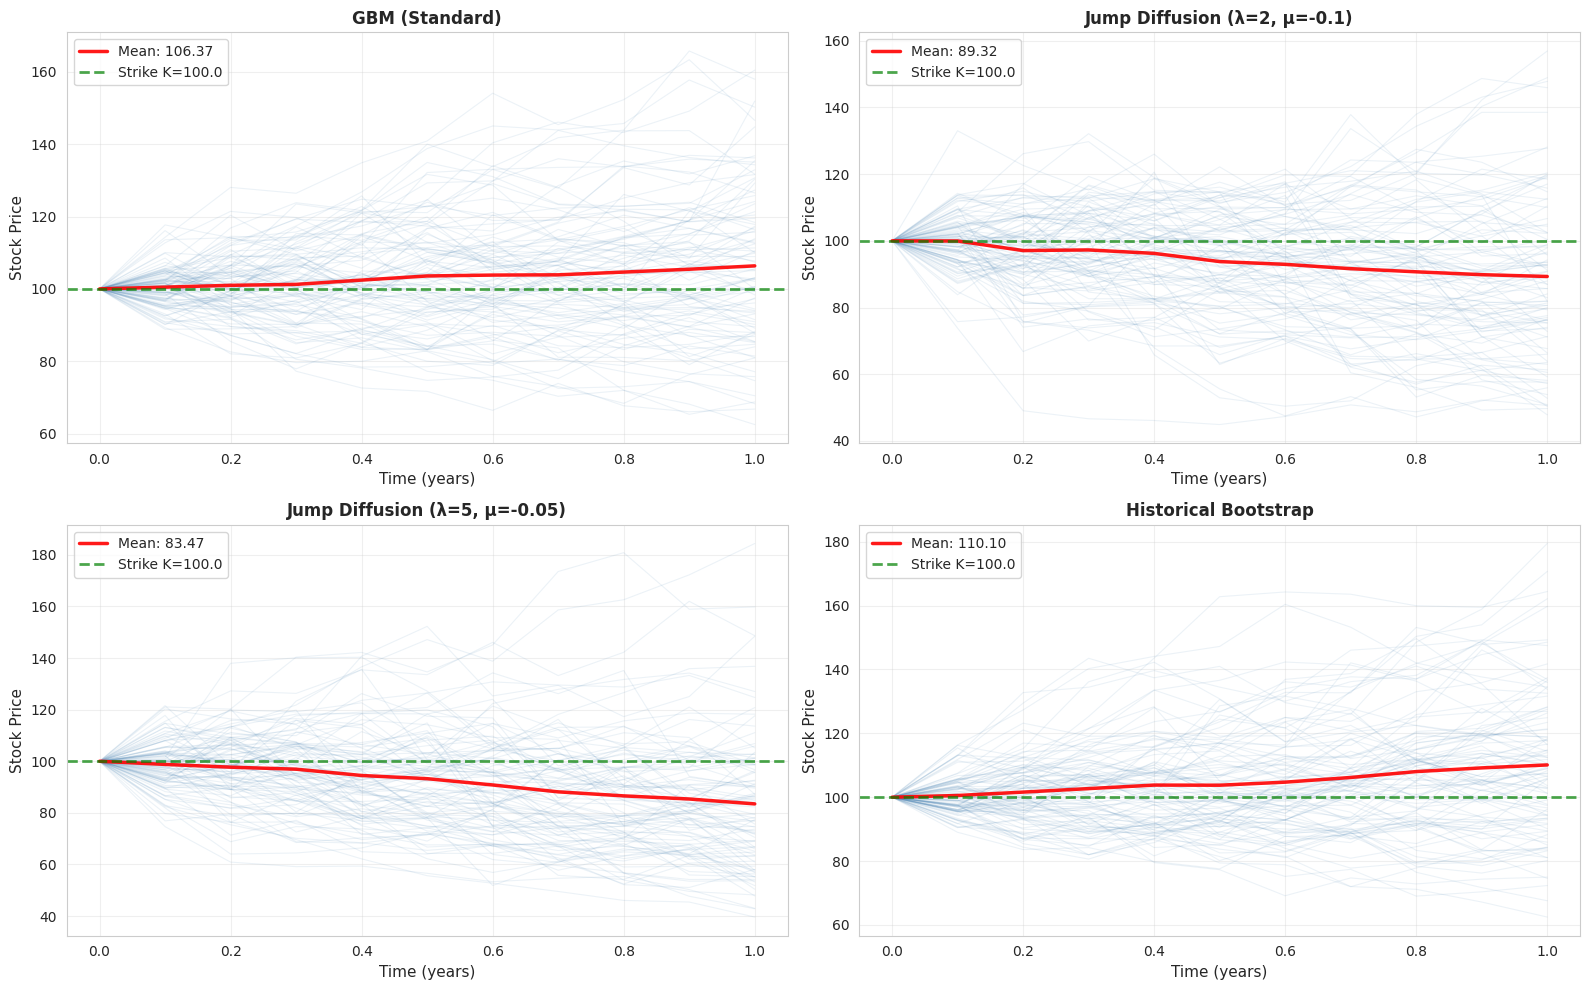


 Comparison Summary:
Generator                                Mean Final Price     Std Final Price
---------------------------------------------------------------------------
GBM (Standard)                           105.80              21.39
Jump Diffusion (λ=2, μ=-0.1)             88.60               27.95
Jump Diffusion (λ=5, μ=-0.05)            84.81               26.47
Historical Bootstrap                     110.96              22.08

Theoretical GBM mean: 105.13
Path generator comparison complete!


In [69]:
# Test different generators
print("Testing Path Generators:\n")

# 1. GBM
gbm_gen = GBMPathGenerator()
gbm_paths = gbm_gen.generate_paths(params, n_paths=3, seed=42)
print("1. GBM Generator:")
print(f"   Shape: {gbm_paths.shape}")
print(f"   First path: {gbm_paths[0, :5]}\n")

# 2. Jump Diffusion
jump_gen = JumpDiffusionPathGenerator(jump_intensity=2.0, jump_mean=-0.1, jump_std=0.15)
jump_paths = jump_gen.generate_paths(params, n_paths=3, seed=42)
print("2. Jump Diffusion Generator:")
print(f"   Shape: {jump_paths.shape}")
print(f"   First path: {jump_paths[0, :5]}\n")

# 3. Historical (simulated example)
historical_returns = np.random.normal(params.r * params.dt, params.sigma * np.sqrt(params.dt), 1000)
hist_gen = HistoricalDataPathGenerator(historical_returns)
hist_paths = hist_gen.generate_paths(params, n_paths=3, seed=42)
print("3. Historical Data Generator:")
print(f"   Shape: {hist_paths.shape}")
print(f"   First path: {hist_paths[0, :5]}\n")

print("All generators working!")



# Visualize and compare different path generators
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

time_grid = np.linspace(0, params.T, params.N + 1)
n_vis = 100

# Generator configurations
generators = [
    ('GBM (Standard)', GBMPathGenerator()),
    ('Jump Diffusion (λ=2, μ=-0.1)', JumpDiffusionPathGenerator(jump_intensity=2.0, jump_mean=-0.1, jump_std=0.15)),
    ('Jump Diffusion (λ=5, μ=-0.05)', JumpDiffusionPathGenerator(jump_intensity=5.0, jump_mean=-0.05, jump_std=0.1)),
    ('Historical Bootstrap', HistoricalDataPathGenerator(historical_returns))
]

for idx, (name, generator) in enumerate(generators):
    ax = axes[idx // 2, idx % 2]
    
    # Generate paths
    paths = generator.generate_paths(params, n_paths=n_vis, seed=42 + idx)
    
    # Plot individual paths (semi-transparent)
    for i in range(n_vis):
        ax.plot(time_grid, paths[i], alpha=0.1, color='steelblue', linewidth=0.8)
    
    # Plot mean path
    mean_path = paths.mean(axis=0)
    ax.plot(time_grid, mean_path, 'r-', linewidth=2.5, label=f'Mean: {mean_path[-1]:.2f}', alpha=0.9)
    
    # Plot strike price
    ax.axhline(y=params.K, color='green', linestyle='--', linewidth=2, label=f'Strike K={params.K}', alpha=0.7)
    
    # Formatting
    ax.set_xlabel('Time (years)', fontsize=11)
    ax.set_ylabel('Stock Price', fontsize=11)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n Comparison Summary:")
print(f"{'Generator':<40} {'Mean Final Price':<20} {'Std Final Price'}")
print("-" * 75)
for name, generator in generators:
    paths = generator.generate_paths(params, n_paths=1000, seed=123)
    final_prices = paths[:, -1]
    print(f"{name:<40} {np.mean(final_prices):<19.2f} {np.std(final_prices):.2f}")

print(f"\nTheoretical GBM mean: {params.S0 * np.exp(params.r * params.T):.2f}")
print("Path generator comparison complete!")

##### Using Real Historical Data

You can easily plug in real market data. Here's an example of how you would use it:

```python
# Example: Load historical stock data (e.g., using yfinance or pandas)
import pandas as pd
# df = pd.read_csv('SPY_data.csv')
# returns = np.log(df['Close'] / df['Close'].shift(1)).dropna().values
# hist_gen = HistoricalDataPathGenerator(returns)
# paths = hist_gen.generate_paths(params, n_paths=1000)
```


### Part 3: Bermudan Put Option Environment

In [70]:
class BermudanPutEnv:
    """
    Environment for Bermudan Put Option pricing.
    
    This implementation works with ANY PathGenerator, not just GBM.
    The environment simulates one full path at reset, then walks through it.
    
    State: (stock_price, time_step)
    Actions: 0 = Continue, 1 = Exercise
    """
    
    def __init__(self, params: OptionParams, generator: PathGenerator = None, seed: Optional[int] = None):
        """
        Args:
            params: Option parameters
            generator: PathGenerator instance (defaults to GBM)
            seed: Random seed for reproducibility
        """
        self.params = params
        self.generator = generator if generator is not None else GBMPathGenerator()
        self.seed = seed
        self.rng = np.random.RandomState(seed)
        
        # Current state
        self.current_path = None
        self.current_step = None
        self.done = False
        
    def reset(self) -> Tuple[float, int]:
        """Reset environment by generating a new path."""
        # Generate a single path using the provided generator
        self.current_path = self.generator.generate_paths(
            self.params, 
            n_paths=1, 
            seed=self.rng.randint(0, 2**31) if self.seed is not None else None
        )[0]  # Take first path
        
        self.current_step = 0
        self.done = False
        return (self.current_path[0], self.current_step)
    
    def step(self, action: int) -> Tuple[Tuple[float, int], float, bool, dict]:
        """
        Take an action in the environment.
        
        Args:
            action: 0 = Continue, 1 = Exercise
            
        Returns:
            next_state: (stock_price, time_step)
            reward: Discounted payoff (if exercised) or 0
            done: Whether episode is finished
            info: Additional information
        """
        if self.done:
            raise ValueError("Episode is done. Call reset().")
        
        if self.current_path is None:
            raise ValueError("Environment not initialized. Call reset() first.")
        
        info = {}
        current_price = self.current_path[self.current_step]
        
        # Calculate immediate payoff
        payoff = max(self.params.K - current_price, 0)
        discount = self.params.discount_factor ** self.current_step
        
        if action == 1:  # Exercise
            reward = discount * payoff
            self.done = True
            info['exercised'] = True
            info['exercise_time'] = self.current_step
            return (current_price, self.current_step), reward, True, info
        
        # Action == 0: Continue
        self.current_step += 1
        
        # Check if we've reached maturity
        if self.current_step >= self.params.N:
            # Automatic exercise at maturity
            final_price = self.current_path[self.current_step]
            payoff = max(self.params.K - final_price, 0)
            reward = discount * self.params.discount_factor * payoff  # One more discount
            self.done = True
            info['exercised'] = True
            info['exercise_time'] = self.current_step
            return (final_price, self.current_step), reward, True, info
        
        # Move to next price on the path
        next_price = self.current_path[self.current_step]
        
        return (next_price, self.current_step), 0.0, False, info
    
    def payoff(self, stock_price: float) -> float:
        """Calculate intrinsic value (payoff) at given stock price."""
        return max(self.params.K - stock_price, 0)

# Test the environment with different generators
print("Testing BermudanPutEnv with different generators:\n")

# Test 1: GBM (default)
print("1. GBM Generator:")
env_gbm = BermudanPutEnv(params, seed=42)
state = env_gbm.reset()
print(f"   Initial state: S={state[0]:.2f}, t={state[1]}")
state, reward, done, info = env_gbm.step(0)  # Continue
print(f"   After continue: S={state[0]:.2f}, t={state[1]}, reward={reward:.4f}\n")

# Test 2: Jump Diffusion
print("2. Jump Diffusion Generator:")
jump_gen = JumpDiffusionPathGenerator(jump_intensity=2.0, jump_mean=-0.1, jump_std=0.15)
env_jump = BermudanPutEnv(params, generator=jump_gen, seed=42)
state = env_jump.reset()
print(f"   Initial state: S={state[0]:.2f}, t={state[1]}")
state, reward, done, info = env_jump.step(0)  # Continue
print(f"   After continue: S={state[0]:.2f}, t={state[1]}, reward={reward:.4f}\n")

# Test 3: Historical
print("3. Historical Data Generator:")
env_hist = BermudanPutEnv(params, generator=hist_gen, seed=42)
state = env_hist.reset()
print(f"   Initial state: S={state[0]:.2f}, t={state[1]}")
state, reward, done, info = env_hist.step(1)  # Exercise immediately
print(f"   Exercise immediately: reward={reward:.4f}, done={done}\n")

print("Environment works with all generator types!")

Testing BermudanPutEnv with different generators:

1. GBM Generator:
   Initial state: S=100.00, t=0
   After continue: S=108.56, t=1, reward=0.0000

2. Jump Diffusion Generator:
   Initial state: S=100.00, t=0
   After continue: S=108.56, t=1, reward=0.0000

3. Historical Data Generator:
   Initial state: S=100.00, t=0
   Exercise immediately: reward=0.0000, done=True

Environment works with all generator types!


### Part 4: Longstaff-Schwartz Algorithm (Benchmark)

In [71]:
class LongstaffSchwartzPolicy:
    """
    Longstaff-Schwartz policy that can be trained and then evaluated.
    
    This implementation separates the training phase (fitting regressions)
    from the evaluation phase (using the learned policy).
    """
    
    def __init__(self, params: OptionParams, poly_degree: int = 3, use_sklearn: bool = False):
        self.params = params
        self.poly_degree = poly_degree
        self.use_sklearn = use_sklearn
        self.models = {}  # t -> regression coefficients or sklearn model
        self.is_trained = False
    
    def train(self, training_paths: np.ndarray):
        """Train the policy by fitting regressions on training paths."""
        print(f"Training LSM policy on {len(training_paths)} paths...")
        start_time = time.time()
        
        if self.use_sklearn:
            try:
                from sklearn.preprocessing import PolynomialFeatures
                from sklearn.linear_model import Ridge
            except ImportError:
                self.use_sklearn = False
        
        payoffs = np.maximum(self.params.K - training_paths, 0)
        cash_flows = payoffs[:, -1].copy()
        
        # Backward induction - fit regression at each time step
        for t in range(self.params.N - 1, 0, -1):
            itm = payoffs[:, t] > 0
            
            if np.sum(itm) == 0:
                cash_flows *= self.params.discount_factor
                continue
            
            S_itm = training_paths[itm, t]
            continuation_values = cash_flows[itm] * self.params.discount_factor
            
            # Fit regression and STORE the model
            if self.use_sklearn:
                poly = PolynomialFeatures(degree=self.poly_degree, include_bias=True)
                X = poly.fit_transform(S_itm.reshape(-1, 1))
                model = Ridge(alpha=1.0)
                model.fit(X, continuation_values)
                self.models[t] = ('sklearn', poly, model)
                continuation_estimate = model.predict(X)
            else:
                X = np.vander(S_itm, self.poly_degree + 1, increasing=True)
                try:
                    coeffs = np.linalg.lstsq(X, continuation_values, rcond=None)[0]
                    self.models[t] = ('numpy', coeffs)
                    continuation_estimate = X @ coeffs
                except:
                    mean_val = np.mean(continuation_values)
                    self.models[t] = ('mean', mean_val)
                    continuation_estimate = np.full(len(S_itm), mean_val)
            
            immediate_exercise = payoffs[itm, t]
            exercise = immediate_exercise > continuation_estimate
            
            itm_indices = np.where(itm)[0]
            exercise_indices = itm_indices[exercise]
            cash_flows[exercise_indices] = immediate_exercise[exercise]
            
            continue_indices = itm_indices[~exercise]
            cash_flows[continue_indices] *= self.params.discount_factor
            
            otm_indices = np.where(~itm)[0]
            cash_flows[otm_indices] *= self.params.discount_factor
        
        self.is_trained = True
        training_time = time.time() - start_time
        print(f"LSM policy trained in {training_time:.2f}s")
        return training_time
    
    def predict(self, stock_price: float, time_step: int) -> int:
        """Predict action using the trained policy."""
        if not self.is_trained:
            raise ValueError("Policy not trained. Call train() first.")
        
        if time_step >= self.params.N:
            return 1
        
        immediate_payoff = max(self.params.K - stock_price, 0)
        if immediate_payoff == 0:
            return 0
        
        if time_step not in self.models:
            return 0
        
        model_info = self.models[time_step]
        
        if model_info[0] == 'sklearn':
            _, poly, model = model_info
            X = poly.transform([[stock_price]])
            continuation_estimate = model.predict(X)[0]
        elif model_info[0] == 'numpy':
            coeffs = model_info[1]
            X = np.array([stock_price ** i for i in range(self.poly_degree + 1)])
            continuation_estimate = np.dot(X, coeffs)
        else:
            continuation_estimate = model_info[1]
        
        return 1 if immediate_payoff > continuation_estimate else 0
    
    def get_policy_function(self):
        return lambda s, t: self.predict(s, t)


def longstaff_schwartz(params: OptionParams, n_paths: int = 10000, 
                       poly_degree: int = 3, seed: Optional[int] = None,
                       generator: PathGenerator = None,
                       use_sklearn: bool = False) -> Tuple[float, np.ndarray, np.ndarray]:
    """
    Price Bermudan Put using LSM algorithm (PRICING, not policy learning).
    
    NOTE: For fair comparison with RL, use LongstaffSchwartzPolicy instead.
    """
    if use_sklearn:
        try:
            from sklearn.preprocessing import PolynomialFeatures
            from sklearn.linear_model import Ridge
        except ImportError:
            use_sklearn = False
    
    paths = simulate_stock_paths(params, n_paths, seed, generator)
    payoffs = np.maximum(params.K - paths, 0)
    cash_flows = payoffs[:, -1].copy()
    exercise_times = np.full(n_paths, params.N)
    
    for t in range(params.N - 1, 0, -1):
        itm = payoffs[:, t] > 0
        
        if np.sum(itm) == 0:
            cash_flows *= params.discount_factor
            continue
        
        S_itm = paths[itm, t]
        continuation_values = cash_flows[itm] * params.discount_factor
        
        if use_sklearn:
            poly = PolynomialFeatures(degree=poly_degree, include_bias=True)
            X = poly.fit_transform(S_itm.reshape(-1, 1))
            model = Ridge(alpha=1.0)
            model.fit(X, continuation_values)
            continuation_estimate = model.predict(X)
        else:
            X = np.vander(S_itm, poly_degree + 1, increasing=True)
            try:
                coeffs = np.linalg.lstsq(X, continuation_values, rcond=None)[0]
                continuation_estimate = X @ coeffs
            except:
                continuation_estimate = np.full(len(S_itm), np.mean(continuation_values))
        
        immediate_exercise = payoffs[itm, t]
        exercise = immediate_exercise > continuation_estimate
        
        itm_indices = np.where(itm)[0]
        exercise_indices = itm_indices[exercise]
        cash_flows[exercise_indices] = immediate_exercise[exercise]
        exercise_times[exercise_indices] = t
        
        continue_indices = itm_indices[~exercise]
        cash_flows[continue_indices] *= params.discount_factor
        
        otm_indices = np.where(~itm)[0]
        cash_flows[otm_indices] *= params.discount_factor
    
    cash_flows *= params.discount_factor
    return np.mean(cash_flows), exercise_times, cash_flows


print("Testing LSM pricing algorithm...\n")
start_time = time.time()
ls_price, ls_exercise_times, ls_cash_flows = longstaff_schwartz(
    params, n_paths=10000, seed=42, use_sklearn=False
)
ls_time = time.time() - start_time

print(f"LSM Pricing: {ls_price:.4f} (time: {ls_time:.2f}s)")
print(f"\nNote: For fair comparison with RL, we'll use LongstaffSchwartzPolicy")
print(f"      which trains on training paths and evaluates on test paths.")

Testing LSM pricing algorithm...

LSM Pricing: 6.1240 (time: 0.01s)

Note: For fair comparison with RL, we'll use LongstaffSchwartzPolicy
      which trains on training paths and evaluates on test paths.


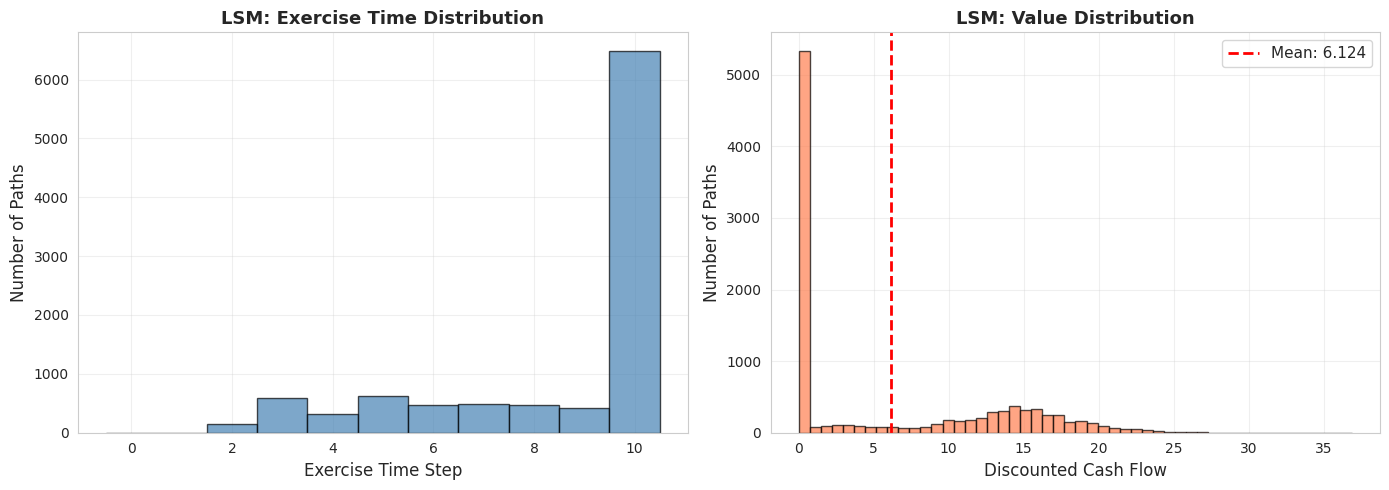


LSM algorithm verified!
Proceeding to structured evaluation framework...


In [72]:
# Quick visualization to verify LSM behavior
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Exercise time distribution
ax1 = axes[0]
ax1.hist(ls_exercise_times, bins=np.arange(0, params.N + 2) - 0.5, 
         alpha=0.7, color='steelblue', edgecolor='black')
ax1.set_xlabel('Exercise Time Step', fontsize=12)
ax1.set_ylabel('Number of Paths', fontsize=12)
ax1.set_title('LSM: Exercise Time Distribution', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Plot 2: Value distribution
ax2 = axes[1]
ax2.hist(ls_cash_flows, bins=50, alpha=0.7, color='coral', edgecolor='black')
ax2.axvline(ls_price, color='red', linestyle='--', linewidth=2, 
           label=f'Mean: {ls_price:.3f}')
ax2.set_xlabel('Discounted Cash Flow', fontsize=12)
ax2.set_ylabel('Number of Paths', fontsize=12)
ax2.set_title('LSM: Value Distribution', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nLSM algorithm verified!")
print("Proceeding to structured evaluation framework...")

In [73]:
# Quick test: LSM works with different generators
print("\n" + "="*70)
print("Verifying LSM works with different path generators")
print("="*70 + "\n")

test_generators = [
    ('GBM', GBMPathGenerator()),
    ('Jump Diffusion', JumpDiffusionPathGenerator(jump_intensity=1.0)),
    ('Historical', hist_gen)
]

for name, gen in test_generators:
    price, ex_times, cf = longstaff_schwartz(params, n_paths=2000, seed=42, generator=gen)
    print(f"{name:20s} -> Price: {price:.4f}, Mean Ex: {np.mean(ex_times):.2f}")

print("\nAll generators compatible with LSM!")
print("Now let's build the proper evaluation framework...")


Verifying LSM works with different path generators

GBM                  -> Price: 6.0844, Mean Ex: 8.68
Jump Diffusion       -> Price: 8.3082, Mean Ex: 8.62
Historical           -> Price: 4.8959, Mean Ex: 8.07

All generators compatible with LSM!
Now let's build the proper evaluation framework...


### Part 5: Comprehensive Testing and Evaluation Framework

In [74]:
@dataclass
class EvaluationResult:
    """Results from evaluating a policy."""
    method_name: str
    mean_value: float
    std_error: float
    values: np.ndarray
    exercise_times: np.ndarray
    training_time: float = 0.0
    
    def summary(self) -> dict:
        """Get summary statistics."""
        return {
            'method': self.method_name,
            'price': self.mean_value,
            'std_error': self.std_error,
            'mean_ex_time': np.mean(self.exercise_times),
            'median_ex_time': np.median(self.exercise_times),
            'training_time': self.training_time
        }


class TestSet:
    """
    TEST SET for fair policy comparison.
    
    IMPORTANT: This is for EVALUATION ONLY. Policies must be trained
    on separate training paths before being evaluated here.
    """
    
    def __init__(self, params: OptionParams, n_paths: int = 5000, 
                 generator: PathGenerator = None, seed: int = 999):
        """
        Args:
            params: Option parameters
            n_paths: Number of test paths
            generator: PathGenerator instance
            seed: Random seed for reproducibility
        """
        self.params = params
        self.n_paths = n_paths
        self.seed = seed
        self.generator = generator if generator is not None else GBMPathGenerator()
        
        # Generate fixed test paths
        print(f"Generating test set: {n_paths} paths with seed={seed}")
        self.paths = simulate_stock_paths(params, n_paths, seed, generator)
        print(f"Test set created. Shape: {self.paths.shape}")
    
    def evaluate_policy(self, policy_fn: Callable, method_name: str,
                       training_time: float = 0.0) -> EvaluationResult:
        """
        Evaluate a policy on the fixed test paths.
        
        Args:
            policy_fn: Function(stock_price, time_step) -> action (0 or 1)
            method_name: Name of the method for reporting
            training_time: Time spent training (for reporting)
            
        Returns:
            EvaluationResult with all metrics
        """
        values = np.zeros(self.n_paths)
        exercise_times = np.full(self.n_paths, self.params.N)
        
        for i in range(self.n_paths):
            path = self.paths[i]
            
            for t in range(self.params.N + 1):
                stock_price = path[t]
                action = policy_fn(stock_price, t)
                
                if action == 1 or t == self.params.N:
                    payoff = max(self.params.K - stock_price, 0)
                    discount = self.params.discount_factor ** t
                    values[i] = discount * payoff
                    exercise_times[i] = t
                    break
        
        mean_value = np.mean(values)
        std_error = np.std(values) / np.sqrt(self.n_paths)
        
        return EvaluationResult(
            method_name=method_name,
            mean_value=mean_value,
            std_error=std_error,
            values=values,
            exercise_times=exercise_times,
            training_time=training_time
        )
    
    def get_lsm_benchmark(self, n_paths: int = 10000) -> EvaluationResult:
        """
        Get LSM price estimate as a benchmark (traditional approach).
        
        This generates its own paths, NOT using the test set.
        It's a reference price for comparison.
        """
        print(f"\nRunning LSM pricing algorithm (benchmark with {n_paths} paths)...")
        
        start_time = time.time()
        ls_price, ls_ex_times, ls_values = longstaff_schwartz(
            self.params, n_paths=n_paths, 
            seed=self.seed - 1,  # Different seed
            generator=self.generator
        )
        ls_time = time.time() - start_time
        
        std_error = np.std(ls_values) / np.sqrt(n_paths)
        
        print(f"LSM Benchmark: {ls_price:.4f} ± {std_error:.4f} ({ls_time:.2f}s)")
        
        return EvaluationResult(
            method_name='LSM Benchmark',
            mean_value=ls_price,
            std_error=std_error,
            values=ls_values,
            exercise_times=ls_ex_times,
            training_time=ls_time
        )
    
    def train_and_evaluate_lsm_policy(self, n_training_paths: int = 10000, 
                                     poly_degree: int = 3) -> EvaluationResult:
        """
        Train LSM policy on training paths, evaluate on test set.
        
        This is the FAIR way to compare with RL:
        1. Generate training paths (separate from test)
        2. Fit LSM regressions on training paths
        3. Evaluate learned policy on test paths
        """
        print(f"\nTraining LSM policy on {n_training_paths} training paths...")
        
        # Generate TRAINING paths (different seed)
        training_paths = simulate_stock_paths(
            self.params, n_training_paths, 
            seed=self.seed + 100,
            generator=self.generator
        )
        
        # Train policy
        lsm_policy = LongstaffSchwartzPolicy(self.params, poly_degree=poly_degree)
        training_time = lsm_policy.train(training_paths)
        
        # Evaluate on test set
        print(f"Evaluating LSM policy on {self.n_paths} test paths...")
        policy_fn = lsm_policy.get_policy_function()
        result = self.evaluate_policy(policy_fn, "LSM Policy", training_time)
        
        print(f"LSM Policy: {result.mean_value:.4f} ± {result.std_error:.4f}")
        
        return result


class ComparisonVisualizer:
    """
    Creates comprehensive visualizations comparing multiple methods.
    """
    
    def __init__(self, results: List[EvaluationResult], params: OptionParams):
        """
        Args:
            results: List of EvaluationResult objects to compare
            params: Option parameters
        """
        self.results = results
        self.params = params
    
    def plot_summary(self, figsize=(18, 12)):
        """
        Create comprehensive comparison plot with all key metrics.
        """
        fig, axes = plt.subplots(2, 3, figsize=figsize)
        
        # Plot 1: Price comparison
        self._plot_prices(axes[0, 0])
        
        # Plot 2: Exercise time distributions
        self._plot_exercise_times(axes[0, 1])
        
        # Plot 3: Value distributions
        self._plot_value_distributions(axes[0, 2])
        
        # Plot 4: Training time comparison
        self._plot_training_times(axes[1, 0])
        
        # Plot 5: Exercise time statistics
        self._plot_exercise_stats(axes[1, 1])
        
        # Plot 6: Summary table
        self._plot_summary_table(axes[1, 2])
        
        plt.tight_layout()
        plt.show()
    
    def _plot_prices(self, ax):
        """Bar chart of option prices."""
        methods = [r.method_name for r in self.results]
        prices = [r.mean_value for r in self.results]
        std_errors = [r.std_error for r in self.results]
        
        colors = ['coral', 'steelblue', 'purple', 'green', 'orange']
        bars = ax.bar(methods, prices, color=colors[:len(methods)],
                     alpha=0.7, edgecolor='black', yerr=std_errors, capsize=5)
        
        ax.set_ylabel('Option Price', fontsize=11)
        ax.set_title('Method Comparison: Option Prices', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')
        ax.tick_params(axis='x', rotation=15)
        
        # Add value labels
        for bar, price, se in zip(bars, prices, std_errors):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{price:.3f}\n±{se:.4f}',
                   ha='center', va='bottom', fontsize=9)
    
    def _plot_exercise_times(self, ax):
        """Histogram of exercise times."""
        bins = np.arange(0, self.params.N + 2) - 0.5
        
        for i, result in enumerate(self.results):
            ax.hist(result.exercise_times, bins=bins, alpha=0.5,
                   label=result.method_name, edgecolor='black')
        
        ax.set_xlabel('Exercise Time Step', fontsize=11)
        ax.set_ylabel('Number of Paths', fontsize=11)
        ax.set_title('Exercise Time Distribution', fontsize=12, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
    
    def _plot_value_distributions(self, ax):
        """Histogram of discounted payoffs."""
        for i, result in enumerate(self.results):
            ax.hist(result.values, bins=50, alpha=0.5,
                   label=f"{result.method_name}: {result.mean_value:.3f}",
                   edgecolor='black')
        
        ax.set_xlabel('Discounted Payoff', fontsize=11)
        ax.set_ylabel('Number of Paths', fontsize=11)
        ax.set_title('Value Distribution', fontsize=12, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
    
    def _plot_training_times(self, ax):
        """Bar chart of training/computation times."""
        methods = [r.method_name for r in self.results]
        times = [r.training_time for r in self.results]
        
        colors = ['coral', 'steelblue', 'purple', 'green', 'orange']
        bars = ax.bar(methods, times, color=colors[:len(methods)],
                     alpha=0.7, edgecolor='black')
        
        ax.set_ylabel('Time (seconds)', fontsize=11)
        ax.set_title('Computation Time', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')
        ax.tick_params(axis='x', rotation=15)
        
        # Add time labels
        for bar, t in zip(bars, times):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{t:.2f}s', ha='center', va='bottom', fontsize=9)
    
    def _plot_exercise_stats(self, ax):
        """Box plot of exercise times."""
        data = [r.exercise_times for r in self.results]
        labels = [r.method_name for r in self.results]
        
        bp = ax.boxplot(data, labels=labels, patch_artist=True)
        
        colors = ['coral', 'steelblue', 'purple', 'green', 'orange']
        for patch, color in zip(bp['boxes'], colors[:len(self.results)]):
            patch.set_facecolor(color)
            patch.set_alpha(0.6)
        
        ax.set_ylabel('Exercise Time Step', fontsize=11)
        ax.set_title('Exercise Time Statistics', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')
        ax.tick_params(axis='x', rotation=15)
    
    def _plot_summary_table(self, ax):
        """Text summary of all results."""
        ax.axis('off')
        
        # Get benchmark (first result, typically LSM)
        benchmark = self.results[0]
        
        summary_lines = [
            "PERFORMANCE SUMMARY",
            "="*45,
            ""
        ]
        
        for result in self.results:
            gap = benchmark.mean_value - result.mean_value
            gap_pct = 100 * gap / benchmark.mean_value if benchmark.mean_value > 0 else 0
            
            summary_lines.extend([
                f"{result.method_name}:",
                f"  Price:      {result.mean_value:.4f}",
                f"  Std Error:  {result.std_error:.4f}",
                f"  Gap:        {gap:.4f} ({gap_pct:.2f}%)",
                f"  Mean Ex:    {np.mean(result.exercise_times):.2f}",
                f"  Time:       {result.training_time:.2f}s",
                ""
            ])
        
        summary_lines.extend([
            "Notes:",
            "- All RL values are lower bounds",
            "- True value >= max(RL values)",
            "- Gap shows distance from benchmark"
        ])
        
        summary_text = "\n".join(summary_lines)
        
        ax.text(0.05, 0.95, summary_text, transform=ax.transAxes,
               fontsize=9, verticalalignment='top', fontfamily='monospace',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    def print_summary_table(self):
        """Print a formatted summary table."""
        print("\n" + "="*90)
        print("EVALUATION SUMMARY")
        print("="*90)
        
        df_data = []
        benchmark = self.results[0]
        
        for result in self.results:
            gap = benchmark.mean_value - result.mean_value
            gap_pct = 100 * gap / benchmark.mean_value if benchmark.mean_value > 0 else 0
            
            df_data.append({
                'Method': result.method_name,
                'Price': f"{result.mean_value:.4f}",
                'Std Error': f"{result.std_error:.4f}",
                'Gap': f"{gap:.4f} ({gap_pct:.2f}%)",
                'Mean Ex Time': f"{np.mean(result.exercise_times):.2f}",
                'Comp Time (s)': f"{result.training_time:.2f}"
            })
        
        df = pd.DataFrame(df_data)
        print(df.to_string(index=False))
        print("="*90 + "\n")


# Test evaluation framework
print("="*70)
print("TESTING EVALUATION FRAMEWORK")
print("="*70)

test_set = TestSet(params, n_paths=5000, seed=999)

print("\n" + "="*70)
print("1. NAIVE POLICIES")
print("="*70)

def always_exercise(s, t):
    return 1

result1 = test_set.evaluate_policy(always_exercise, "Always Exercise")
print(f"Always Exercise: {result1.mean_value:.4f}")

def never_exercise(s, t):
    return 0

result2 = test_set.evaluate_policy(never_exercise, "Never Exercise")
print(f"Never Exercise: {result2.mean_value:.4f}")

def threshold_policy(s, t):
    return 1 if s < params.K * 0.9 else 0

result3 = test_set.evaluate_policy(threshold_policy, "Threshold")
print(f"Threshold (0.9K): {result3.mean_value:.4f}")

print("\n" + "="*70)
print("2. LSM BENCHMARK (Traditional - Reference Price)")
print("="*70)
lsm_benchmark = test_set.get_lsm_benchmark(n_paths=10000)

print("\n" + "="*70)
print("3. LSM POLICY (Fair Comparison - Train/Test Split)")
print("="*70)
lsm_policy_result = test_set.train_and_evaluate_lsm_policy(n_training_paths=10000)

print("\n" + "="*70)
print("COMPARISON")
print("="*70)
print(f"\nLSM Benchmark: {lsm_benchmark.mean_value:.4f} (traditional pricing)")
print(f"LSM Policy:    {lsm_policy_result.mean_value:.4f} (train/test split)")
print(f"Gap:           {lsm_benchmark.mean_value - lsm_policy_result.mean_value:.4f}")

TESTING EVALUATION FRAMEWORK
Generating test set: 5000 paths with seed=999
Test set created. Shape: (5000, 11)

1. NAIVE POLICIES
Always Exercise: 0.0000
Never Exercise: 5.6370
Threshold (0.9K): 5.9221

2. LSM BENCHMARK (Traditional - Reference Price)

Running LSM pricing algorithm (benchmark with 10000 paths)...
LSM Benchmark: 6.0768 ± 0.0738 (0.01s)

3. LSM POLICY (Fair Comparison - Train/Test Split)

Training LSM policy on 10000 training paths...
Training LSM policy on 10000 paths...
LSM policy trained in 0.01s
Evaluating LSM policy on 5000 test paths...
LSM Policy: 6.0012 ± 0.1049

COMPARISON

LSM Benchmark: 6.0768 (traditional pricing)
LSM Policy:    6.0012 (train/test split)
Gap:           0.0756


## Part 6: Tabular Q-Learning

**Q-Learning** learns a Q-table: Q(s, a) = expected value of taking action a in state s.

**Challenge**: Continuous state space (stock price). 
**Solution**: Discretize stock prices into bins.

**Algorithm**:
1. Initialize Q(s, a) for all discretized states and actions
2. For each episode:
   - Generate a path
   - At each step, choose action (epsilon-greedy)
   - Update: Q(s,a) <- Q(s,a) + alpha * (reward + gamma * max_a' Q(s',a') - Q(s,a))
3. Learned policy: pi(s) = argmax_a Q(s,a)

In [75]:
class QLearningAgent:
    """
    Tabular Q-Learning for Bermudan option pricing.
    
    State space is discretized into bins for stock prices x time steps.
    """
    
    def __init__(self, params: OptionParams, n_price_bins: int = 50,
                 learning_rate: float = 0.1, epsilon: float = 0.1,
                 price_range: Tuple[float, float] = None):
        """
        Args:
            params: Option parameters
            n_price_bins: Number of bins to discretize stock prices
            learning_rate: Alpha parameter for Q-learning updates
            epsilon: Exploration rate for epsilon-greedy
            price_range: (min_price, max_price) for discretization
        """
        self.params = params
        self.n_price_bins = n_price_bins
        self.learning_rate = learning_rate
        self.epsilon = epsilon
        
        # Set price range (default: 3 std deviations)
        if price_range is None:
            # Expected price range based on GBM
            std_multiplier = 3.0
            expected_vol = params.sigma * np.sqrt(params.T)
            price_range = (
                params.S0 * np.exp(-std_multiplier * expected_vol),
                params.S0 * np.exp(std_multiplier * expected_vol)
            )
        
        self.price_min, self.price_max = price_range
        self.price_bins = np.linspace(self.price_min, self.price_max, n_price_bins + 1)
        
        # Q-table: (price_bin, time_step, action)
        # Actions: 0 = Continue, 1 = Exercise
        self.q_table = np.zeros((n_price_bins, params.N + 1, 2))
        
        # Initialize with intrinsic value for exercise action
        for i, price in enumerate(self.price_bins[:-1]):
            intrinsic = max(params.K - price, 0)
            for t in range(params.N + 1):
                discount = params.discount_factor ** t
                self.q_table[i, t, 1] = discount * intrinsic
    
    def discretize_price(self, price: float) -> int:
        """Convert continuous price to discrete bin index."""
        # Clip to valid range
        price = np.clip(price, self.price_min, self.price_max)
        bin_idx = np.digitize(price, self.price_bins) - 1
        return min(bin_idx, self.n_price_bins - 1)
    
    def get_action(self, price: float, time_step: int, training: bool = True) -> int:
        """Select action using epsilon-greedy policy."""
        if training and np.random.random() < self.epsilon:
            return np.random.randint(2)  # Random action
        
        # Greedy action
        price_bin = self.discretize_price(price)
        return int(np.argmax(self.q_table[price_bin, time_step]))
    
    def update(self, state: Tuple[float, int], action: int, reward: float,
               next_state: Tuple[float, int], done: bool):
        """Update Q-table using Q-learning rule."""
        price, time_step = state
        next_price, next_time_step = next_state
        
        price_bin = self.discretize_price(price)
        next_price_bin = self.discretize_price(next_price)
        
        # Current Q-value
        current_q = self.q_table[price_bin, time_step, action]
        
        # Target Q-value
        if done:
            target_q = reward
        else:
            next_max_q = np.max(self.q_table[next_price_bin, next_time_step])
            target_q = reward + next_max_q  # No additional discount (already in reward)
        
        # Q-learning update
        self.q_table[price_bin, time_step, action] += \
            self.learning_rate * (target_q - current_q)
    
    def train(self, env: BermudanPutEnv, n_episodes: int = 1000, verbose: bool = True):
        """Train the Q-learning agent."""
        episode_rewards = []
        
        for episode in range(n_episodes):
            state = env.reset()
            total_reward = 0
            done = False
            
            while not done:
                # Select action
                action = self.get_action(state[0], state[1], training=True)
                
                # Take action
                next_state, reward, done, info = env.step(action)
                
                # Update Q-table
                self.update(state, action, reward, next_state, done)
                
                total_reward += reward
                state = next_state
            
            episode_rewards.append(total_reward)
            
            # Print progress
            if verbose and (episode + 1) % 200 == 0:
                avg_reward = np.mean(episode_rewards[-200:])
                print(f"Episode {episode + 1}/{n_episodes}, Avg Reward (last 200): {avg_reward:.4f}")
        
        return episode_rewards
    
    def get_policy_function(self):
        """Return a policy function for evaluation."""
        def policy(price, time_step):
            return self.get_action(price, time_step, training=False)
        return policy


print("Q-Learning Agent implementation complete!")

Q-Learning Agent implementation complete!


In [76]:
# Train Q-Learning agent
print("="*70)
print("TRAINING Q-LEARNING AGENT")
print("="*70 + "\n")

# Create environment and agent
env_train = BermudanPutEnv(params, seed=42)
agent = QLearningAgent(params, n_price_bins=50, learning_rate=0.1, epsilon=0.1)

# Train
start_time = time.time()
rewards = agent.train(env_train, n_episodes=5000, verbose=True)
training_time = time.time() - start_time

print(f"\nTraining completed in {training_time:.2f}s")

# Evaluate on the test set
print("\nEvaluating Q-Learning policy on test set...")
ql_policy = agent.get_policy_function()
ql_result = test_set.evaluate_policy(ql_policy, "Q-Learning", training_time)

print(f"\nQ-Learning Results:")
print(f"  Price:       {ql_result.mean_value:.4f}")
print(f"  Std Error:   {ql_result.std_error:.4f}")
print(f"  Mean Ex:     {np.mean(ql_result.exercise_times):.2f}")
print(f"  vs LSM Gap:  {lsm_policy_result.mean_value - ql_result.mean_value:.4f}")

TRAINING Q-LEARNING AGENT

Episode 200/5000, Avg Reward (last 200): 2.2761
Episode 400/5000, Avg Reward (last 200): 3.3995
Episode 600/5000, Avg Reward (last 200): 2.8067
Episode 800/5000, Avg Reward (last 200): 3.2314
Episode 1000/5000, Avg Reward (last 200): 4.0286
Episode 1200/5000, Avg Reward (last 200): 3.3222
Episode 1400/5000, Avg Reward (last 200): 3.8009
Episode 1600/5000, Avg Reward (last 200): 3.5713
Episode 1800/5000, Avg Reward (last 200): 4.1609
Episode 2000/5000, Avg Reward (last 200): 3.6906
Episode 2200/5000, Avg Reward (last 200): 4.0983
Episode 2400/5000, Avg Reward (last 200): 4.1961
Episode 2600/5000, Avg Reward (last 200): 4.3330
Episode 2800/5000, Avg Reward (last 200): 3.6708
Episode 3000/5000, Avg Reward (last 200): 3.7108
Episode 3200/5000, Avg Reward (last 200): 3.6691
Episode 3400/5000, Avg Reward (last 200): 4.3814
Episode 3600/5000, Avg Reward (last 200): 3.9759
Episode 3800/5000, Avg Reward (last 200): 3.9887
Episode 4000/5000, Avg Reward (last 200): 4.04

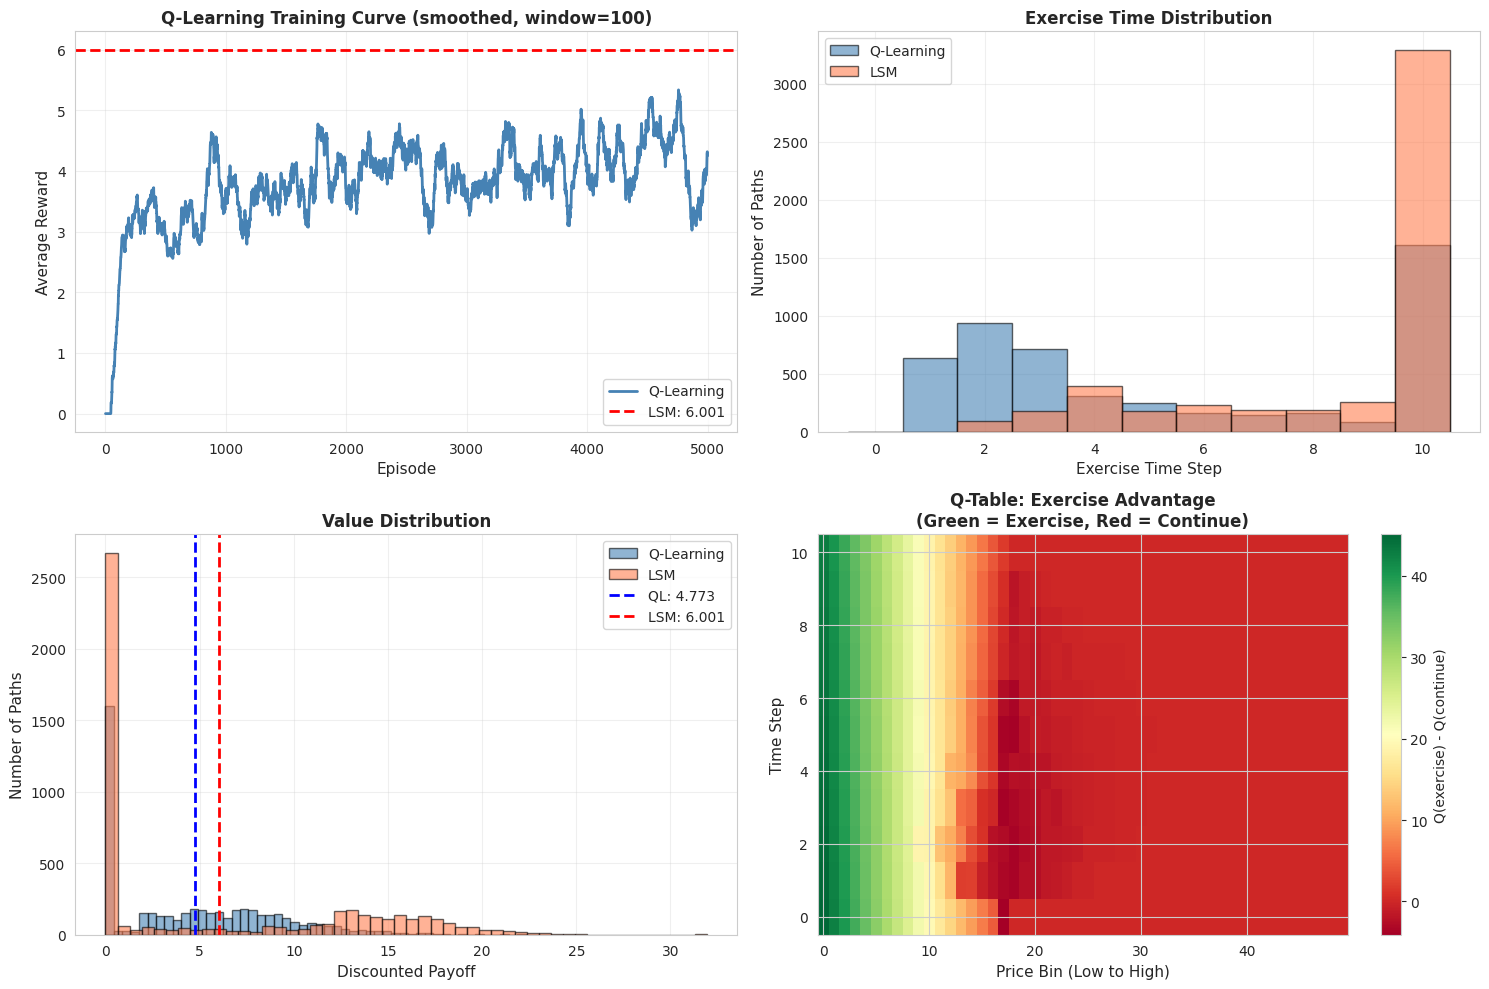


Q-Learning training and evaluation complete!


In [77]:
# Visualize Q-Learning results
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Training curve
ax1 = axes[0, 0]
window = 100
smoothed_rewards = pd.Series(rewards).rolling(window=window, min_periods=1).mean()
ax1.plot(smoothed_rewards, linewidth=2, color='steelblue', label='Q-Learning')
ax1.axhline(y=lsm_policy_result.mean_value, color='red', linestyle='--', 
           linewidth=2, label=f'LSM: {lsm_policy_result.mean_value:.3f}')
ax1.set_xlabel('Episode', fontsize=11)
ax1.set_ylabel('Average Reward', fontsize=11)
ax1.set_title(f'Q-Learning Training Curve (smoothed, window={window})', 
             fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Exercise time distribution comparison
ax2 = axes[0, 1]
bins = np.arange(0, params.N + 2) - 0.5
ax2.hist(ql_result.exercise_times, bins=bins, alpha=0.6, 
        label='Q-Learning', color='steelblue', edgecolor='black')
ax2.hist(lsm_policy_result.exercise_times, bins=bins, alpha=0.6, 
        label='LSM', color='coral', edgecolor='black')
ax2.set_xlabel('Exercise Time Step', fontsize=11)
ax2.set_ylabel('Number of Paths', fontsize=11)
ax2.set_title('Exercise Time Distribution', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Value distribution comparison
ax3 = axes[1, 0]
ax3.hist(ql_result.values, bins=50, alpha=0.6, 
        label='Q-Learning', color='steelblue', edgecolor='black')
ax3.hist(lsm_policy_result.values, bins=50, alpha=0.6, 
        label='LSM', color='coral', edgecolor='black')
ax3.axvline(ql_result.mean_value, color='blue', linestyle='--', 
           linewidth=2, label=f'QL: {ql_result.mean_value:.3f}')
ax3.axvline(lsm_policy_result.mean_value, color='red', linestyle='--', 
           linewidth=2, label=f'LSM: {lsm_policy_result.mean_value:.3f}')
ax3.set_xlabel('Discounted Payoff', fontsize=11)
ax3.set_ylabel('Number of Paths', fontsize=11)
ax3.set_title('Value Distribution', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Q-table heatmap (Continue vs Exercise)
ax4 = axes[1, 1]
advantage = agent.q_table[:, :, 1] - agent.q_table[:, :, 0]
im = ax4.imshow(advantage.T, aspect='auto', cmap='RdYlGn', origin='lower')
ax4.set_xlabel('Price Bin (Low to High)', fontsize=11)
ax4.set_ylabel('Time Step', fontsize=11)
ax4.set_title('Q-Table: Exercise Advantage\n(Green = Exercise, Red = Continue)', 
             fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax4, label='Q(exercise) - Q(continue)')

plt.tight_layout()
plt.show()

print("\nQ-Learning training and evaluation complete!")

## Part 7: Deep Q-Network (DQN)

In [78]:
# Check for PyTorch
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from collections import deque
    import random
    
    TORCH_AVAILABLE = True
    print(f"PyTorch version: {torch.__version__}")
    print(f"CUDA available: {torch.cuda.is_available()}")
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
except ImportError:
    TORCH_AVAILABLE = False
    print("PyTorch not available. Install with: pip install torch")
    print("DQN implementation will be skipped.")

PyTorch version: 2.9.0+cu128
CUDA available: False
Using device: cpu


In [79]:
if TORCH_AVAILABLE:
    
    class QNetwork(nn.Module):
        """Neural network for Q-value approximation."""
        
        def __init__(self, hidden_sizes=[64, 64]):
            super(QNetwork, self).__init__()
            
            # Input: [normalized_price, normalized_time]
            # Output: [Q(continue), Q(exercise)]
            layers = []
            input_size = 2
            
            for hidden_size in hidden_sizes:
                layers.append(nn.Linear(input_size, hidden_size))
                layers.append(nn.ReLU())
                input_size = hidden_size
            
            layers.append(nn.Linear(input_size, 2))  # 2 actions
            
            self.network = nn.Sequential(*layers)
        
        def forward(self, x):
            return self.network(x)
    
    
    class ReplayBuffer:
        """Experience replay buffer."""
        
        def __init__(self, capacity=10000):
            self.buffer = deque(maxlen=capacity)
        
        def push(self, state, action, reward, next_state, done):
            self.buffer.append((state, action, reward, next_state, done))
        
        def sample(self, batch_size):
            return random.sample(self.buffer, batch_size)
        
        def __len__(self):
            return len(self.buffer)
    
    
    class DQNAgent:
        """Deep Q-Network agent for Bermudan option pricing."""
        
        def __init__(self, params: OptionParams, hidden_sizes=[64, 64],
                     learning_rate=0.001, gamma=1.0, epsilon_start=1.0,
                     epsilon_end=0.01, epsilon_decay=0.995, buffer_size=10000):
            """
            Args:
                params: Option parameters
                hidden_sizes: List of hidden layer sizes
                learning_rate: Learning rate for optimizer
                gamma: Discount factor (should be 1.0 for discounted rewards)
                epsilon_start: Initial exploration rate
                epsilon_end: Final exploration rate
                epsilon_decay: Epsilon decay per episode
                buffer_size: Replay buffer capacity
            """
            self.params = params
            self.gamma = gamma
            self.epsilon = epsilon_start
            self.epsilon_end = epsilon_end
            self.epsilon_decay = epsilon_decay
            
            # Normalization constants
            self.price_mean = params.S0
            self.price_std = params.S0 * params.sigma * np.sqrt(params.T)
            
            # Networks
            self.policy_net = QNetwork(hidden_sizes).to(device)
            self.target_net = QNetwork(hidden_sizes).to(device)
            self.target_net.load_state_dict(self.policy_net.state_dict())
            self.target_net.eval()
            
            # Optimizer and loss
            self.optimizer = optim.Adam(self.policy_net.parameters(), lr=learning_rate)
            self.criterion = nn.MSELoss()
            
            # Replay buffer
            self.memory = ReplayBuffer(buffer_size)
        
        def normalize_state(self, state: Tuple[float, int]) -> torch.Tensor:
            """Normalize state for neural network input."""
            price, time_step = state
            norm_price = (price - self.price_mean) / self.price_std
            norm_time = time_step / self.params.N
            return torch.tensor([norm_price, norm_time], dtype=torch.float32, device=device)
        
        def get_action(self, state: Tuple[float, int], training: bool = True) -> int:
            """Select action using epsilon-greedy policy."""
            if training and random.random() < self.epsilon:
                return random.randint(0, 1)
            
            with torch.no_grad():
                state_tensor = self.normalize_state(state).unsqueeze(0)
                q_values = self.policy_net(state_tensor)
                return int(q_values.argmax().item())
        
        def update(self, batch_size=64):
            """Update network using a batch from replay buffer."""
            if len(self.memory) < batch_size:
                return
            
            # Sample batch
            batch = self.memory.sample(batch_size)
            states, actions, rewards, next_states, dones = zip(*batch)
            
            # Convert to tensors
            state_batch = torch.stack([self.normalize_state(s) for s in states])
            action_batch = torch.tensor(actions, dtype=torch.long, device=device)
            reward_batch = torch.tensor(rewards, dtype=torch.float32, device=device)
            next_state_batch = torch.stack([self.normalize_state(s) for s in next_states])
            done_batch = torch.tensor(dones, dtype=torch.float32, device=device)
            
            # Current Q-values
            current_q = self.policy_net(state_batch).gather(1, action_batch.unsqueeze(1)).squeeze()
            
            # Target Q-values
            with torch.no_grad():
                next_q = self.target_net(next_state_batch).max(1)[0]
                target_q = reward_batch + (1 - done_batch) * self.gamma * next_q
            
            # Compute loss and update
            loss = self.criterion(current_q, target_q)
            
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()
            
            return loss.item()
        
        def train(self, env: BermudanPutEnv, n_episodes: int = 1000,
                 batch_size: int = 64, target_update_freq: int = 10, verbose: bool = True):
            """Train the DQN agent."""
            episode_rewards = []
            losses = []
            
            for episode in range(n_episodes):
                state = env.reset()
                total_reward = 0
                done = False
                
                while not done:
                    # Select and perform action
                    action = self.get_action(state, training=True)
                    next_state, reward, done, info = env.step(action)
                    
                    # Store transition
                    self.memory.push(state, action, reward, next_state, done)
                    
                    # Update network
                    if len(self.memory) >= batch_size:
                        loss = self.update(batch_size)
                        if loss is not None:
                            losses.append(loss)
                    
                    total_reward += reward
                    state = next_state
                
                episode_rewards.append(total_reward)
                
                # Decay epsilon
                self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)
                
                # Update target network
                if (episode + 1) % target_update_freq == 0:
                    self.target_net.load_state_dict(self.policy_net.state_dict())
                
                # Print progress
                if verbose and (episode + 1) % 200 == 0:
                    avg_reward = np.mean(episode_rewards[-200:])
                    avg_loss = np.mean(losses[-200:]) if losses else 0
                    print(f"Episode {episode + 1}/{n_episodes}, Avg Reward: {avg_reward:.4f}, "
                          f"Avg Loss: {avg_loss:.4f}, Epsilon: {self.epsilon:.3f}")
            
            return episode_rewards, losses
        
        def get_policy_function(self):
            """Return a policy function for evaluation."""
            def policy(price, time_step):
                return self.get_action((price, time_step), training=False)
            return policy
    
    print("DQN Agent implementation complete!")
else:
    print("Skipping DQN implementation (PyTorch not available)")

DQN Agent implementation complete!


In [80]:
if TORCH_AVAILABLE:
    print("\n" + "="*70)
    print("TRAINING DQN AGENT")
    print("="*70 + "\n")
    
    # Create environment and agent
    env_train_dqn = BermudanPutEnv(params, seed=42)
    dqn_agent = DQNAgent(params, hidden_sizes=[64, 64], learning_rate=0.001,
                         epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.995)
    
    # Train
    start_time = time.time()
    dqn_rewards, dqn_losses = dqn_agent.train(env_train_dqn, n_episodes=3000,
                                               batch_size=64, target_update_freq=10, 
                                               verbose=True)
    dqn_training_time = time.time() - start_time
    
    print(f"\nDQN training completed in {dqn_training_time:.2f}s")
    
    # Evaluate on the test set
    print("\nEvaluating DQN policy on test set...")
    dqn_policy = dqn_agent.get_policy_function()
    dqn_result = test_set.evaluate_policy(dqn_policy, "DQN", dqn_training_time)
    
    print(f"\nDQN Results:")
    print(f"  Price:       {dqn_result.mean_value:.4f}")
    print(f"  Std Error:   {dqn_result.std_error:.4f}")
    print(f"  Mean Ex:     {np.mean(dqn_result.exercise_times):.2f}")
    print(f"  vs LSM Gap:  {lsm_policy_result.mean_value - dqn_result.mean_value:.4f}")
    print(f"  vs Q-L Gap:  {ql_result.mean_value - dqn_result.mean_value:.4f}")
else:
    print("Skipping DQN training (PyTorch not available)")


TRAINING DQN AGENT

Episode 200/3000, Avg Reward: 2.4282, Avg Loss: 4.1102, Epsilon: 0.367
Episode 400/3000, Avg Reward: 5.6605, Avg Loss: 6.8129, Epsilon: 0.135
Episode 600/3000, Avg Reward: 4.8452, Avg Loss: 7.6247, Epsilon: 0.049
Episode 800/3000, Avg Reward: 4.9774, Avg Loss: 7.5390, Epsilon: 0.018
Episode 1000/3000, Avg Reward: 6.7188, Avg Loss: 7.9514, Epsilon: 0.010
Episode 1200/3000, Avg Reward: 5.4088, Avg Loss: 8.0513, Epsilon: 0.010
Episode 1400/3000, Avg Reward: 6.7999, Avg Loss: 7.2583, Epsilon: 0.010
Episode 1600/3000, Avg Reward: 6.5287, Avg Loss: 7.1171, Epsilon: 0.010
Episode 1800/3000, Avg Reward: 5.9548, Avg Loss: 7.1061, Epsilon: 0.010
Episode 2000/3000, Avg Reward: 5.1525, Avg Loss: 6.8757, Epsilon: 0.010
Episode 2200/3000, Avg Reward: 5.7248, Avg Loss: 6.4474, Epsilon: 0.010
Episode 2400/3000, Avg Reward: 5.3036, Avg Loss: 7.2210, Epsilon: 0.010
Episode 2600/3000, Avg Reward: 5.3075, Avg Loss: 6.6815, Epsilon: 0.010
Episode 2800/3000, Avg Reward: 5.3655, Avg Loss


COMPREHENSIVE COMPARISON OF ALL METHODS


EVALUATION SUMMARY
    Method  Price Std Error             Gap Mean Ex Time Comp Time (s)
LSM Policy 6.0012    0.1049  0.0000 (0.00%)         8.52          0.01
Q-Learning 4.7734    0.0619 1.2278 (20.46%)         5.44          0.72
       DQN 5.9215    0.0880  0.0797 (1.33%)         7.34         81.88



/tmp/ipykernel_6279/1271047893.py:270: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True)


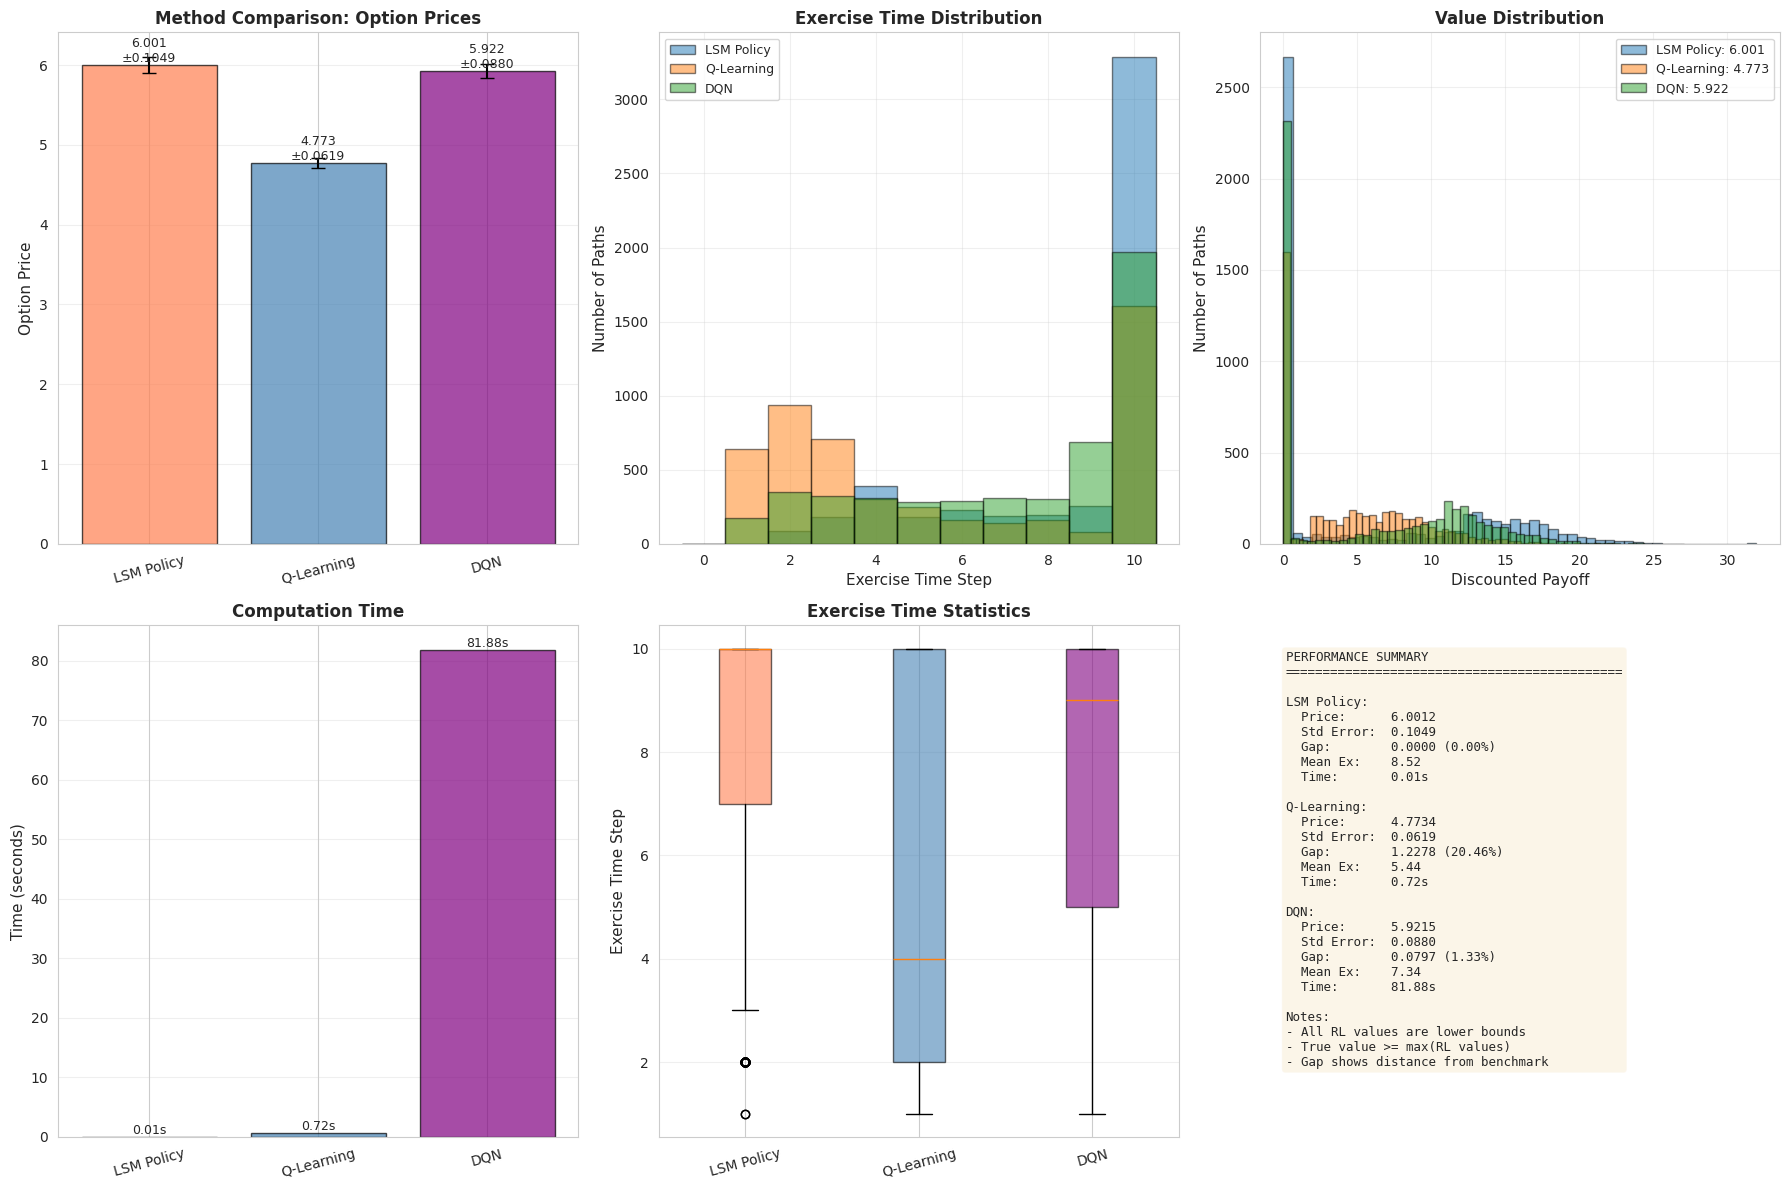

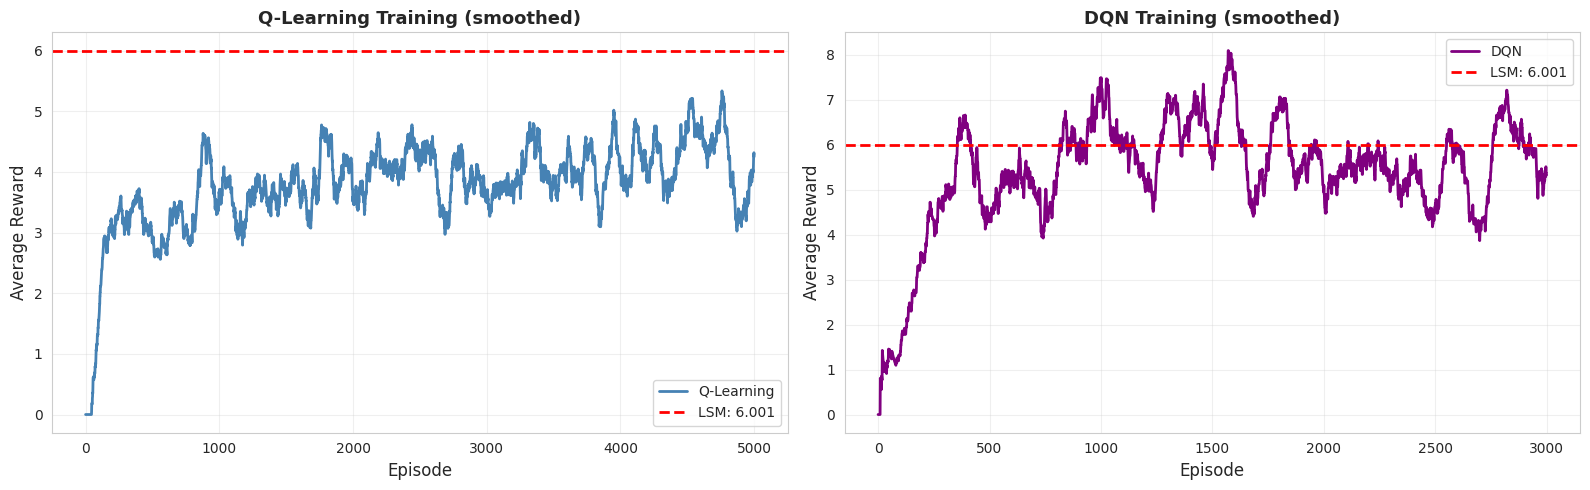


All methods evaluated and compared!
Note: All evaluations use the SAME test set for fair comparison.


In [81]:
if TORCH_AVAILABLE:
    print("\n" + "="*70)
    print("COMPREHENSIVE COMPARISON OF ALL METHODS")
    print("="*70 + "\n")
    
    # Collect all results for comparison
    all_results = [lsm_policy_result, ql_result, dqn_result]
    
    # Create visualizer and generate comprehensive plots
    visualizer = ComparisonVisualizer(all_results, params)
    
    # Print summary table
    visualizer.print_summary_table()
    
    # Plot comprehensive comparison
    visualizer.plot_summary(figsize=(18, 12))
    
    # Additional plot: Training curves side by side
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Q-Learning training curve
    ax1 = axes[0]
    window = 100
    smoothed_ql = pd.Series(rewards).rolling(window=window, min_periods=1).mean()
    ax1.plot(smoothed_ql, linewidth=2, color='steelblue', label='Q-Learning')
    ax1.axhline(y=lsm_policy_result.mean_value, color='red', linestyle='--', 
               linewidth=2, label=f'LSM: {lsm_policy_result.mean_value:.3f}')
    ax1.set_xlabel('Episode', fontsize=12)
    ax1.set_ylabel('Average Reward', fontsize=12)
    ax1.set_title(f'Q-Learning Training (smoothed)', fontsize=13, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # DQN training curve
    ax2 = axes[1]
    smoothed_dqn = pd.Series(dqn_rewards).rolling(window=window, min_periods=1).mean()
    ax2.plot(smoothed_dqn, linewidth=2, color='purple', label='DQN')
    ax2.axhline(y=lsm_policy_result.mean_value, color='red', linestyle='--', 
               linewidth=2, label=f'LSM: {lsm_policy_result.mean_value:.3f}')
    ax2.set_xlabel('Episode', fontsize=12)
    ax2.set_ylabel('Average Reward', fontsize=12)
    ax2.set_title(f'DQN Training (smoothed)', fontsize=13, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\nAll methods evaluated and compared!")
    print("Note: All evaluations use the SAME test set for fair comparison.")
else:
    print("Skipping DQN comparison (PyTorch not available)")

## Part 8: Multi-Asset Option Pricing

In [82]:
@dataclass
class MultiAssetOptionParams:
    """Parameters for Multi-Asset Bermudan Options"""
    S0: np.ndarray          # Initial prices [S1_0, S2_0, ..., Sn_0]
    K: float = 100.0        # Strike price
    T: float = 1.0          # Time to maturity
    r: float = 0.05         # Risk-free rate
    sigma: np.ndarray = None  # Volatilities [σ1, σ2, ..., σn]
    rho: np.ndarray = None    # Correlation matrix (n x n)
    N: int = 10             # Number of exercise dates
    weights: np.ndarray = None  # Basket weights (for basket options)
    
    def __post_init__(self):
        self.n_assets = len(self.S0)
        
        # Default: all assets have same volatility
        if self.sigma is None:
            self.sigma = np.full(self.n_assets, 0.2)
        
        # Default: identity correlation (independent)
        if self.rho is None:
            self.rho = np.eye(self.n_assets)
        
        # Default: equal weights
        if self.weights is None:
            self.weights = np.ones(self.n_assets) / self.n_assets
        
        # Compute covariance matrix
        self.cov = np.outer(self.sigma, self.sigma) * self.rho
    
    @property
    def dt(self) -> float:
        return self.T / self.N
    
    @property
    def discount_factor(self) -> float:
        return np.exp(-self.r * self.dt)
    
    def __str__(self):
        return (f"Multi-Asset Bermudan: n={self.n_assets}, S0={self.S0}, K={self.K}, "
                f"T={self.T}, r={self.r:.2%}, N={self.N}")


# Example: 2-asset basket option
params_2d = MultiAssetOptionParams(
    S0=np.array([100.0, 100.0]),
    K=100.0,
    sigma=np.array([0.2, 0.25]),
    rho=np.array([[1.0, 0.5],
                  [0.5, 1.0]]),  # 50% correlation
    weights=np.array([0.5, 0.5])  # Equal weight basket
)

print(params_2d)
print(f"\nCovariance matrix:")
print(params_2d.cov)
print(f"\nWeights: {params_2d.weights}")

Multi-Asset Bermudan: n=2, S0=[100. 100.], K=100.0, T=1.0, r=5.00%, N=10

Covariance matrix:
[[0.04   0.025 ]
 [0.025  0.0625]]

Weights: [0.5 0.5]



Generating 2-asset correlated paths...

Shape: (100, 11, 2)
  n_paths=100
  time_steps=11
  n_assets=2


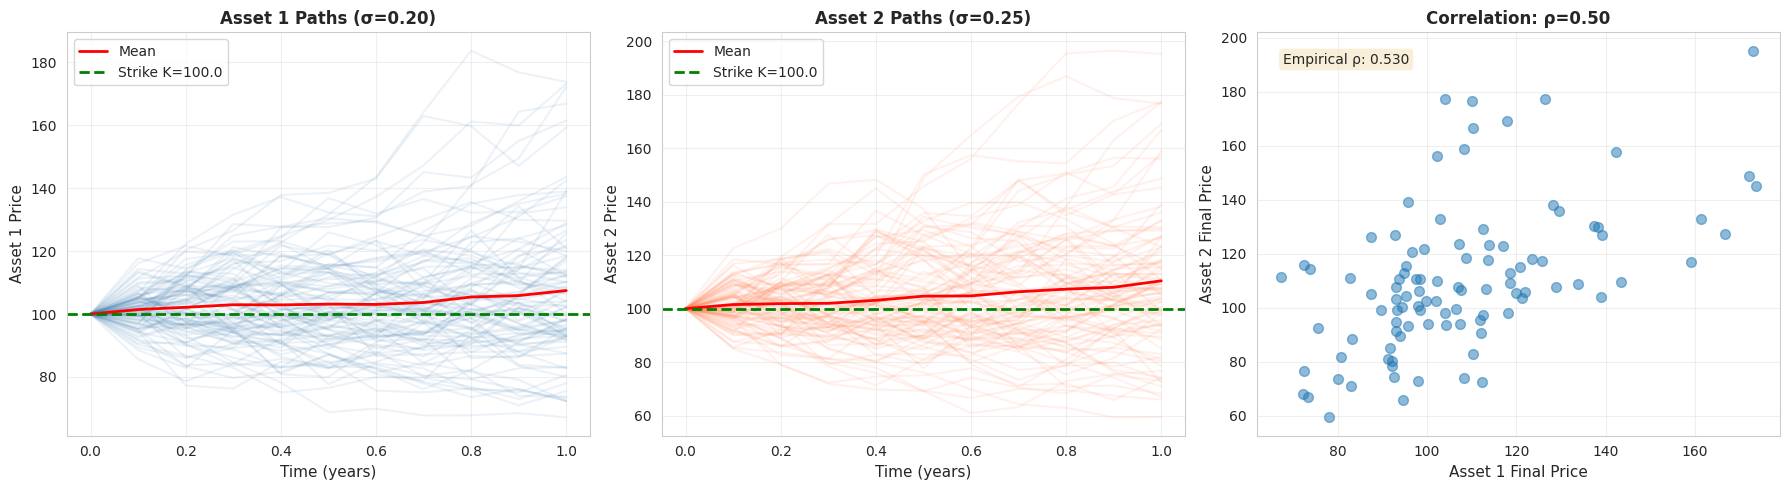


Empirical correlation: 0.5303 (target: 0.50)


In [83]:
class MultiAssetGBMPathGenerator(PathGenerator):
    """
    Correlated GBM path generator for multiple assets.
    
    Uses Cholesky decomposition to generate correlated Brownian motions.
    
    Model for asset i:
        dS_i = r * S_i * dt + σ_i * S_i * dW_i
    
    where dW_i are correlated Brownian increments with correlation matrix ρ.
    """
    
    def __init__(self, params: MultiAssetOptionParams):
        self.params = params
        # Cholesky decomposition for correlation
        self.L = np.linalg.cholesky(params.rho)
    
    def generate_paths(self, params: MultiAssetOptionParams, n_paths: int, 
                      seed: Optional[int] = None) -> np.ndarray:
        """
        Generate correlated multi-asset paths.
        
        Returns:
            paths: Array of shape (n_paths, N+1, n_assets)
                   paths[i, t, j] = price of asset j at time t on path i
        """
        if seed is not None:
            np.random.seed(seed)
        
        n_assets = params.n_assets
        N = params.N
        dt = params.dt
        
        # Initialize paths: (n_paths, N+1, n_assets)
        paths = np.zeros((n_paths, N + 1, n_assets))
        paths[:, 0, :] = params.S0  # Initial prices
        
        # Generate independent standard normals
        Z_independent = np.random.standard_normal((n_paths, N, n_assets))
        
        # Apply Cholesky to get correlated normals
        Z_correlated = Z_independent @ self.L.T
        
        # Simulate each asset
        for j in range(n_assets):
            drift = (params.r - 0.5 * params.sigma[j]**2) * dt
            diffusion = params.sigma[j] * np.sqrt(dt)
            
            for t in range(N):
                paths[:, t + 1, j] = paths[:, t, j] * np.exp(
                    drift + diffusion * Z_correlated[:, t, j]
                )
        
        return paths


# Test: Generate and visualize 2-asset paths
print("\nGenerating 2-asset correlated paths...\n")

gen_2d = MultiAssetGBMPathGenerator(params_2d)
paths_2d = gen_2d.generate_paths(params_2d, n_paths=100, seed=42)

print(f"Shape: {paths_2d.shape}")
print(f"  n_paths={paths_2d.shape[0]}")
print(f"  time_steps={paths_2d.shape[1]}")
print(f"  n_assets={paths_2d.shape[2]}")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
time_grid = np.linspace(0, params_2d.T, params_2d.N + 1)

# Plot Asset 1
ax1 = axes[0]
for i in range(100):
    ax1.plot(time_grid, paths_2d[i, :, 0], alpha=0.1, color='steelblue')
ax1.plot(time_grid, paths_2d[:, :, 0].mean(axis=0), 'r-', linewidth=2, label='Mean')
ax1.axhline(params_2d.K, color='green', linestyle='--', linewidth=2, label=f'Strike K={params_2d.K}')
ax1.set_xlabel('Time (years)', fontsize=11)
ax1.set_ylabel('Asset 1 Price', fontsize=11)
ax1.set_title('Asset 1 Paths (σ=0.20)', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot Asset 2
ax2 = axes[1]
for i in range(100):
    ax2.plot(time_grid, paths_2d[i, :, 1], alpha=0.1, color='coral')
ax2.plot(time_grid, paths_2d[:, :, 1].mean(axis=0), 'r-', linewidth=2, label='Mean')
ax2.axhline(params_2d.K, color='green', linestyle='--', linewidth=2, label=f'Strike K={params_2d.K}')
ax2.set_xlabel('Time (years)', fontsize=11)
ax2.set_ylabel('Asset 2 Price', fontsize=11)
ax2.set_title('Asset 2 Paths (σ=0.25)', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Scatter: Final prices (shows correlation)
ax3 = axes[2]
final_prices_1 = paths_2d[:, -1, 0]
final_prices_2 = paths_2d[:, -1, 1]
ax3.scatter(final_prices_1, final_prices_2, alpha=0.5, s=50)
ax3.set_xlabel('Asset 1 Final Price', fontsize=11)
ax3.set_ylabel('Asset 2 Final Price', fontsize=11)
ax3.set_title(f'Correlation: ρ={params_2d.rho[0,1]:.2f}', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Compute empirical correlation
emp_corr = np.corrcoef(final_prices_1, final_prices_2)[0, 1]
ax3.text(0.05, 0.95, f'Empirical ρ: {emp_corr:.3f}', 
        transform=ax3.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"\nEmpirical correlation: {emp_corr:.4f} (target: {params_2d.rho[0,1]:.2f})")

In [84]:
class MultiAssetBermudanPutEnv:
    """
    Environment for Multi-Asset Bermudan Put Options.
    
    Payoff types:
    - 'basket': Put on weighted average of assets
    - 'max': Put on maximum of assets
    - 'min': Put on minimum of assets
    
    State: ([S1_t, S2_t, ..., Sn_t], t)
    Actions: 0 = Continue, 1 = Exercise
    """
    
    def __init__(self, params: MultiAssetOptionParams, 
                 generator: MultiAssetGBMPathGenerator = None,
                 payoff_type: str = 'basket',
                 seed: Optional[int] = None):
        """
        Args:
            params: Multi-asset option parameters
            generator: Multi-asset path generator
            payoff_type: 'basket', 'max', or 'min'
            seed: Random seed
        """
        self.params = params
        self.generator = generator if generator is not None else MultiAssetGBMPathGenerator(params)
        self.payoff_type = payoff_type
        self.seed = seed
        self.rng = np.random.RandomState(seed)
        
        # Current state
        self.current_path = None
        self.current_step = None
        self.done = False
    
    def reset(self) -> Tuple[np.ndarray, int]:
        """Reset environment by generating a new path."""
        # Generate single path: shape (1, N+1, n_assets)
        paths = self.generator.generate_paths(
            self.params,
            n_paths=1,
            seed=self.rng.randint(0, 2**31) if self.seed is not None else None
        )
        self.current_path = paths[0]  # Shape: (N+1, n_assets)
        
        self.current_step = 0
        self.done = False
        return (self.current_path[0], self.current_step)
    
    def step(self, action: int) -> Tuple[Tuple[np.ndarray, int], float, bool, dict]:
        """Take action in environment."""
        if self.done:
            raise ValueError("Episode done. Call reset().")
        
        if self.current_path is None:
            raise ValueError("Call reset() first.")
        
        info = {}
        current_prices = self.current_path[self.current_step]
        
        # Calculate payoff based on type
        payoff = self._calculate_payoff(current_prices)
        discount = self.params.discount_factor ** self.current_step
        
        if action == 1:  # Exercise
            reward = discount * payoff
            self.done = True
            info['exercised'] = True
            info['exercise_time'] = self.current_step
            return (current_prices, self.current_step), reward, True, info
        
        # Continue
        self.current_step += 1
        
        # Check maturity
        if self.current_step >= self.params.N:
            final_prices = self.current_path[self.current_step]
            payoff = self._calculate_payoff(final_prices)
            reward = discount * self.params.discount_factor * payoff
            self.done = True
            info['exercised'] = True
            info['exercise_time'] = self.current_step
            return (final_prices, self.current_step), reward, True, info
        
        next_prices = self.current_path[self.current_step]
        return (next_prices, self.current_step), 0.0, False, info
    
    def _calculate_payoff(self, prices: np.ndarray) -> float:
        """Calculate payoff based on type."""
        if self.payoff_type == 'basket':
            # Weighted average
            basket_value = np.dot(self.params.weights, prices)
            return max(self.params.K - basket_value, 0)
        elif self.payoff_type == 'max':
            # Put on maximum
            max_price = np.max(prices)
            return max(self.params.K - max_price, 0)
        elif self.payoff_type == 'min':
            # Put on minimum
            min_price = np.min(prices)
            return max(self.params.K - min_price, 0)
        else:
            raise ValueError(f"Unknown payoff type: {self.payoff_type}")


# Test multi-asset environment
print("Testing Multi-Asset Environment:\n")

env_2d = MultiAssetBermudanPutEnv(params_2d, payoff_type='basket', seed=42)

print("Test 1: Basket option")
state = env_2d.reset()
print(f"  Initial: S={state[0]}, t={state[1]}")
print(f"  Basket value: {np.dot(params_2d.weights, state[0]):.2f}")

state, reward, done, info = env_2d.step(0)  # Continue
print(f"  After continue: S={state[0]}, t={state[1]}, reward={reward:.4f}")

state, reward, done, info = env_2d.step(1)  # Exercise
print(f"  Exercise: reward={reward:.4f}, done={done}\n")

# Test max option
env_max = MultiAssetBermudanPutEnv(params_2d, payoff_type='max', seed=42)
state = env_max.reset()
print("Test 2: Max option")
print(f"  Initial: S={state[0]}")
print(f"  Max price: {np.max(state[0]):.2f}")
state, reward, done, info = env_max.step(1)
print(f"  Exercise: reward={reward:.4f}\n")

print("Multi-asset environment working!")

Testing Multi-Asset Environment:

Test 1: Basket option
  Initial: S=[100. 100.], t=0
  Basket value: 100.00
  After continue: S=[108.55730053 104.04519214], t=1, reward=0.0000
  Exercise: reward=0.0000, done=True

Test 2: Max option
  Initial: S=[100. 100.]
  Max price: 100.00
  Exercise: reward=0.0000

Multi-asset environment working!


### Multi-Asset Architecture: Reusing Existing Algorithms

### Multi-Asset Longstaff-Schwartz Method

For multi-asset options, LSM requires multi-dimensional regression. We use basis functions that capture:
- Individual asset prices: S1, S2, ..., Sn
- Cross-terms: S1*S2, S1*S3, etc.
- Higher-order terms: S1^2, S2^2, etc.

**Basis functions for 2 assets:**
- 1, S1, S2, S1^2, S2^2, S1*S2

In [85]:
def multi_asset_basis(prices: np.ndarray) -> np.ndarray:
    """
    Generate basis functions for multi-asset LSM regression.
    
    Args:
        prices: Shape (n_paths, n_assets) - current asset prices
    
    Returns:
        basis: Shape (n_paths, n_basis) - basis function values
    """
    n_paths, n_assets = prices.shape
    
    basis_list = [np.ones(n_paths)]  # Constant
    
    # Linear terms
    for j in range(n_assets):
        basis_list.append(prices[:, j])
    
    # Quadratic terms
    for j in range(n_assets):
        basis_list.append(prices[:, j]**2)
    
    # Cross terms (for 2 or more assets)
    if n_assets >= 2:
        for i in range(n_assets):
            for j in range(i+1, n_assets):
                basis_list.append(prices[:, i] * prices[:, j])
    
    return np.column_stack(basis_list)


class MultiAssetLSMPolicy:
    """
    Multi-Asset Longstaff-Schwartz policy.
    
    Learns continuation values using regression on multi-asset basis functions.
    """
    
    def __init__(self, params: MultiAssetOptionParams, payoff_type: str = 'basket'):
        self.params = params
        self.payoff_type = payoff_type
        self.regression_coeffs = {}  # {time_step: coefficients}
        self.trained = False
    
    def _calculate_payoff(self, prices: np.ndarray) -> np.ndarray:
        """Calculate payoff for array of price vectors."""
        if self.payoff_type == 'basket':
            basket_values = prices @ self.params.weights
            return np.maximum(self.params.K - basket_values, 0)
        elif self.payoff_type == 'max':
            max_prices = np.max(prices, axis=1)
            return np.maximum(self.params.K - max_prices, 0)
        elif self.payoff_type == 'min':
            min_prices = np.min(prices, axis=1)
            return np.maximum(self.params.K - min_prices, 0)
        else:
            raise ValueError(f"Unknown payoff type: {self.payoff_type}")
    
    def train(self, paths: np.ndarray) -> float:
        """
        Train LSM policy on given paths.
        
        Args:
            paths: Shape (n_paths, N+1, n_assets) - training paths
        
        Returns:
            training_time: Time taken to train
        """
        start_time = time.time()
        
        n_paths = paths.shape[0]
        N = self.params.N
        discount = self.params.discount_factor
        
        # Initialize cash flows at maturity
        final_prices = paths[:, N, :]
        cash_flows = self._calculate_payoff(final_prices)
        exercise_times = np.full(n_paths, N)
        
        # Backward induction
        for t in range(N - 1, 0, -1):
            current_prices = paths[:, t, :]
            immediate_payoff = self._calculate_payoff(current_prices)
            
            # Only regress on ITM paths
            itm = immediate_payoff > 0
            
            if np.sum(itm) > 0:
                # Discounted future cash flows
                discounted_cf = discount * cash_flows[itm]
                
                # Regression
                X = multi_asset_basis(current_prices[itm])
                
                try:
                    coeffs = np.linalg.lstsq(X, discounted_cf, rcond=None)[0]
                    continuation_value = X @ coeffs
                    
                    # Exercise decision
                    exercise = immediate_payoff[itm] > continuation_value
                    
                    # Update cash flows and exercise times
                    itm_indices = np.where(itm)[0]
                    for i, idx in enumerate(itm_indices):
                        if exercise[i]:
                            cash_flows[idx] = immediate_payoff[idx]
                            exercise_times[idx] = t
                    
                    # Store coefficients
                    self.regression_coeffs[t] = coeffs
                except np.linalg.LinAlgError:
                    # If regression fails, don't exercise at this step
                    self.regression_coeffs[t] = None
            
            # Discount all cash flows
            cash_flows = discount * cash_flows
        
        self.trained = True
        training_time = time.time() - start_time
        return training_time
    
    def predict(self, prices: np.ndarray, time_step: int) -> int:
        """
        Predict exercise decision for given state.
        
        Args:
            prices: Array of shape (n_assets,) - current asset prices
            time_step: Current time step
        
        Returns:
            action: 0 = Continue, 1 = Exercise
        """
        if not self.trained:
            raise ValueError("Policy not trained. Call train() first.")
        
        if time_step >= self.params.N:
            return 1  # Exercise at maturity
        
        if time_step == 0:
            return 0  # Never exercise at t=0 for Bermudan
        
        # Check if we have regression for this time step
        if time_step not in self.regression_coeffs or self.regression_coeffs[time_step] is None:
            return 0  # Default to continue
        
        # Calculate immediate payoff
        immediate_payoff = self._calculate_payoff(prices.reshape(1, -1))[0]
        
        if immediate_payoff <= 0:
            return 0  # OTM, don't exercise
        
        # Estimate continuation value
        basis = multi_asset_basis(prices.reshape(1, -1))
        continuation_value = basis @ self.regression_coeffs[time_step]
        
        return 1 if immediate_payoff > continuation_value else 0
    
    def get_policy_function(self):
        """Return policy function for evaluation."""
        return lambda prices, time_step: self.predict(prices, time_step)


print("Multi-Asset LSM Policy implemented!")

Multi-Asset LSM Policy implemented!


### Multi-Asset Utilities and Evaluation

In [86]:
class MultiAssetEnvWrapper:
    """
    Wrapper to make multi-asset environment compatible with existing DQN implementation.
    
    Flattens state (prices, time_step) into a single vector.
    """
    
    def __init__(self, env: MultiAssetBermudanPutEnv):
        self.env = env
        self.n_assets = env.params.n_assets
        self.N = env.params.N
        
        # For normalization
        self.price_mean = env.params.S0
        self.price_std = env.params.S0 * env.params.sigma * np.sqrt(env.params.T)
    
    def reset(self):
        """Reset and return flattened state."""
        prices, time_step = self.env.reset()
        state = self._flatten_state(prices, time_step)
        return state, {}
    
    def step(self, action):
        """Step and return flattened next state."""
        (prices, time_step), reward, done, info = self.env.step(action)
        next_state = self._flatten_state(prices, time_step)
        return next_state, reward, done, False, info
    
    def _flatten_state(self, prices, time_step):
        """Flatten (prices, time_step) into normalized vector."""
        # Normalize prices
        norm_prices = (prices - self.price_mean) / self.price_std
        # Normalize time
        norm_time = time_step / self.N
        # Concatenate: [S1_norm, S2_norm, ..., Sn_norm, t_norm]
        return np.concatenate([norm_prices, [norm_time]])
    
    @property
    def action_space(self):
        """Mock action space for DQN."""
        class ActionSpace:
            n = 2  # Continue or Exercise
        return ActionSpace()


print("Multi-asset environment wrapper created!")

Multi-asset environment wrapper created!


In [87]:
@dataclass
class PolicyResult:
    """Results from evaluating a policy."""
    name: str
    values: np.ndarray
    exercise_times: np.ndarray
    training_time: float
    episode_rewards: Optional[List[float]] = None
    
    @property
    def mean(self) -> float:
        return np.mean(self.values)
    
    @property
    def std_error(self) -> float:
        return np.std(self.values) / np.sqrt(len(self.values))
    
    @property
    def avg_exercise_time(self) -> float:
        return np.mean(self.exercise_times)


def evaluate_policy_on_paths(paths: np.ndarray, policy_fn: Callable, 
                             params: MultiAssetOptionParams) -> Tuple[np.ndarray, np.ndarray]:
    """Evaluate policy on test paths."""
    n_paths, N = paths.shape[0], params.N
    values, exercise_times = np.zeros(n_paths), np.zeros(n_paths, dtype=int)
    
    for i in range(n_paths):
        for t in range(N + 1):
            prices = paths[i, t]
            action = 1 if t == N else policy_fn(prices, t)
            
            if action == 1:
                basket_val = prices @ params.weights
                payoff = max(params.K - basket_val, 0)
                values[i] = (params.discount_factor ** t) * payoff
                exercise_times[i] = t
                break
    
    return values, exercise_times


def plot_comparison(results: List[PolicyResult], params: MultiAssetOptionParams, 
                   figsize=(16, 10)):
    """Modular comparison plot for any number of policies."""
    n_results = len(results)
    colors = plt.cm.tab10(np.linspace(0, 1, n_results))
    
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    
    # 1. Price comparison
    ax = axes[0, 0]
    names, means, errors = [], [], []
    for r in results:
        names.append(r.name)
        means.append(r.mean)
        errors.append(r.std_error)
    
    ax.bar(names, means, yerr=errors, capsize=8, color=colors, alpha=0.7, 
           edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Price')
    ax.set_title(f'{params.n_assets}-Asset: Price Comparison', fontweight='bold')
    ax.grid(True, axis='y', alpha=0.3)
    for i, (m, e) in enumerate(zip(means, errors)):
        ax.text(i, m + e, f'{m:.3f}', ha='center', va='bottom', fontsize=9)
    
    # 2. Training time
    ax = axes[0, 1]
    times = [r.training_time for r in results]
    ax.bar(names, times, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Time (s)')
    ax.set_title('Training Time', fontweight='bold')
    ax.set_yscale('log')
    ax.grid(True, axis='y', alpha=0.3)
    for i, t in enumerate(times):
        ax.text(i, t, f'{t:.1f}s', ha='center', va='bottom', fontsize=9)
    
    # 3. Exercise times
    ax = axes[1, 0]
    for r, c in zip(results, colors):
        ax.hist(r.exercise_times, bins=params.N, alpha=0.5, label=r.name, 
                color=c, edgecolor='black')
    ax.set_xlabel('Exercise Time')
    ax.set_ylabel('Frequency')
    ax.set_title('Exercise Time Distribution', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 4. Value distributions
    ax = axes[1, 1]
    for r, c in zip(results, colors):
        ax.hist(r.values, bins=40, alpha=0.5, label=f'{r.name}: {r.mean:.3f}',
                color=c, edgecolor='black', density=True)
        ax.axvline(r.mean, color=c, linestyle='--', linewidth=2)
    ax.set_xlabel('Option Value')
    ax.set_ylabel('Density')
    ax.set_title('Value Distribution', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def print_results_table(results: List[PolicyResult]):
    """Print comparison table."""
    data = {
        'Method': [r.name for r in results],
        'Price': [f'{r.mean:.4f}' for r in results],
        'Std Error': [f'{r.std_error:.4f}' for r in results],
        'Train Time (s)': [f'{r.training_time:.2f}' for r in results],
        'Avg Ex. Time': [f'{r.avg_exercise_time:.2f}' for r in results]
    }
    df = pd.DataFrame(data)
    print("\n" + "="*80)
    print(df.to_string(index=False))
    print("="*80)
    
    # Gap analysis
    if len(results) >= 2:
        baseline = results[0]
        for r in results[1:]:
            gap = r.mean - baseline.mean
            gap_pct = 100 * gap / baseline.mean if baseline.mean > 0 else 0
            sig = abs(gap) / np.sqrt(r.std_error**2 + baseline.std_error**2)
            print(f"{r.name} vs {baseline.name}: {gap:+.4f} ({gap_pct:+.2f}%), {sig:.2f} std devs")


print("Evaluation utilities created!")

Evaluation utilities created!


In [88]:
from src.algorithms import DQNAgent, linear_decay_schedule
print("DQN imported!")

DQN imported!


### Experiment: 2-Asset Basket Option

In [89]:
# Setup
N_TRAIN = 5000
N_TEST = 1000

# Generate paths
train_paths_2d = gen_2d.generate_paths(params_2d, N_TRAIN, seed=100)
test_paths_2d = gen_2d.generate_paths(params_2d, N_TEST, seed=999)

# Train LSM
print("Training LSM...")
lsm_2d = MultiAssetLSMPolicy(params_2d, 'basket')
lsm_time = lsm_2d.train(train_paths_2d)

# Train DQN
print("Training DQN...")
env_train = MultiAssetBermudanPutEnv(params_2d, gen_2d, 'basket', seed=42)
wrapped_env = MultiAssetEnvWrapper(env_train)

dqn_2d = DQNAgent(
    state_dim=params_2d.n_assets + 1,
    action_dim=2,
    hidden_dims=[64, 64],
    learning_rate=0.001,
    gamma=1.0,
    epsilon_schedule=linear_decay_schedule(1.0, 0.01, int(N_TRAIN * 0.7)),
    batch_size=64,
    target_update_freq=50,
    seed=42
)

start = time.time()
dqn_2d.train(wrapped_env, n_episodes=N_TRAIN, verbose=1, use_tqdm=True)
dqn_time = time.time() - start

print(f"LSM: {lsm_time:.2f}s, DQN: {dqn_time:.2f}s")

Training LSM...
Training DQN...


Training DQN:   0%|          | 0/5000 [00:00<?, ?it/s]

LSM: 0.01s, DQN: 56.31s


Evaluating...

Method  Price Std Error Train Time (s) Avg Ex. Time
   LSM 5.7925    0.2171           0.01         8.25
   DQN 5.7227    0.2255          56.31         7.87
DQN vs LSM: -0.0697 (-1.20%), 0.22 std devs


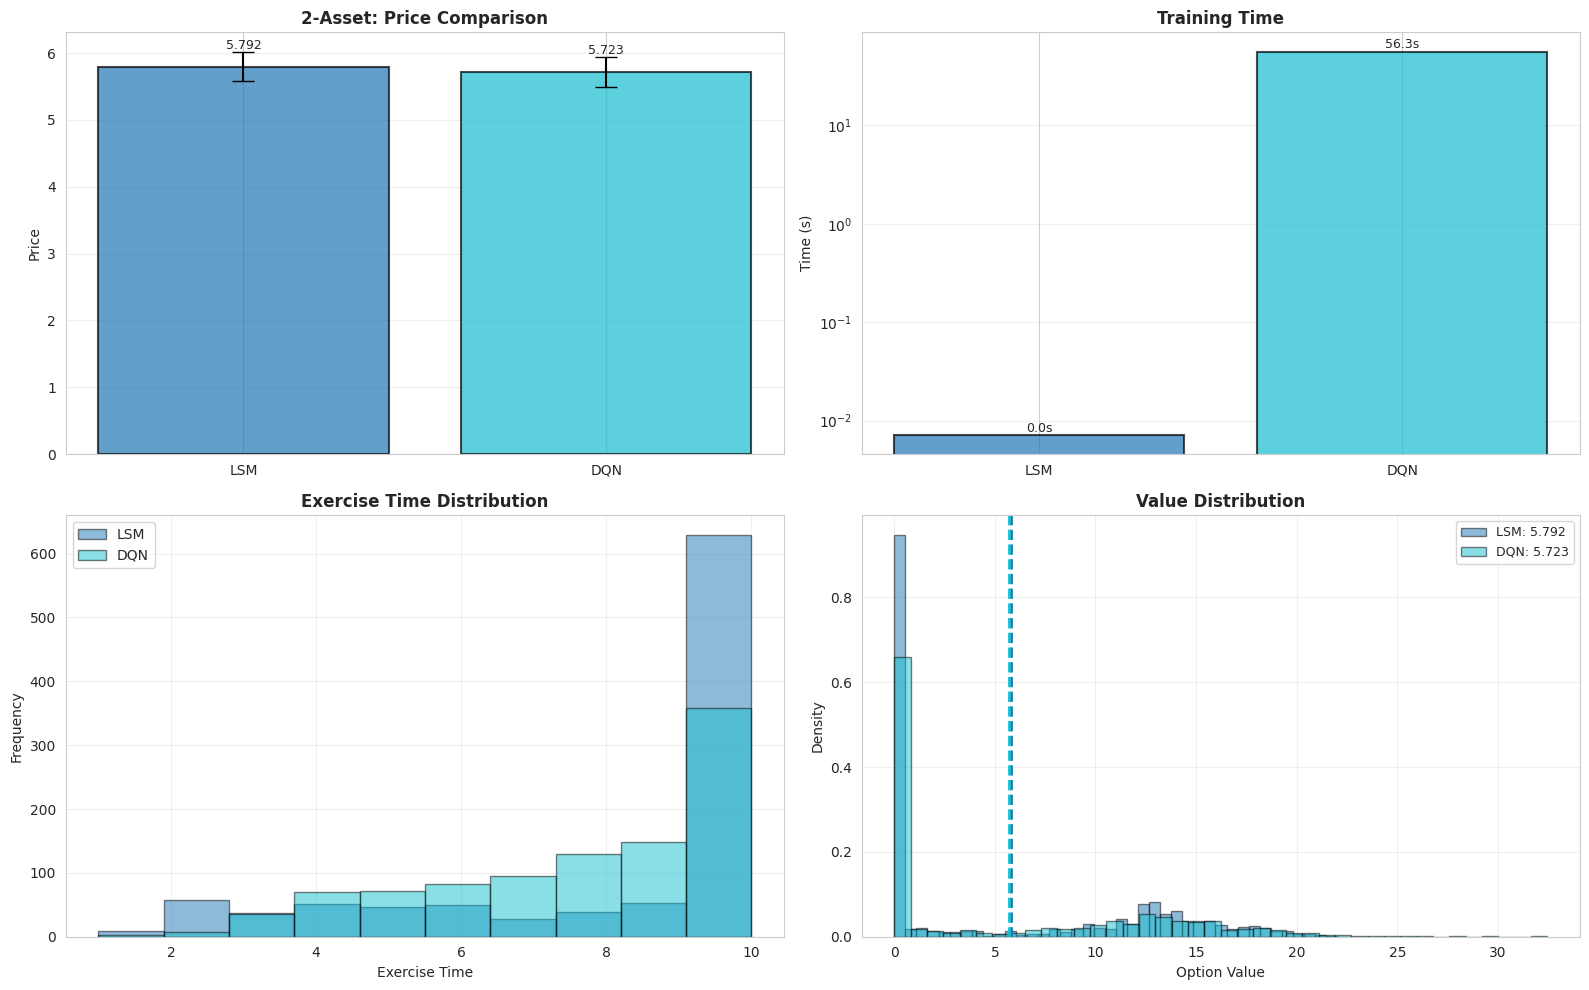

In [90]:
# Evaluate
print("Evaluating...")

def dqn_policy_2d(prices, t):
    norm_prices = (prices - params_2d.S0) / (params_2d.S0 * params_2d.sigma * np.sqrt(params_2d.T))
    state = np.concatenate([norm_prices, [t / params_2d.N]])
    with torch.no_grad():
        state_t = torch.FloatTensor(state).unsqueeze(0).to(dqn_2d.device)
        return dqn_2d.policy_net(state_t).argmax(dim=1).item()

lsm_vals, lsm_ex = evaluate_policy_on_paths(test_paths_2d, lsm_2d.get_policy_function(), params_2d)
dqn_vals, dqn_ex = evaluate_policy_on_paths(test_paths_2d, dqn_policy_2d, params_2d)

results_2d = [
    PolicyResult("LSM", lsm_vals, lsm_ex, lsm_time),
    PolicyResult("DQN", dqn_vals, dqn_ex, dqn_time, dqn_2d.episode_rewards)
]

print_results_table(results_2d)
plot_comparison(results_2d, params_2d)

### Experiment: 3-Asset Basket Option

In [91]:
# 3-asset parameters
params_3d = MultiAssetOptionParams(
    S0=np.array([100.0, 100.0, 100.0]),
    K=100.0,
    sigma=np.array([0.2, 0.25, 0.3]),
    rho=np.array([[1.0, 0.5, 0.3], [0.5, 1.0, 0.4], [0.3, 0.4, 1.0]]),
    weights=np.array([0.4, 0.3, 0.3])
)
gen_3d = MultiAssetGBMPathGenerator(params_3d)

# Generate and train
train_paths_3d = gen_3d.generate_paths(params_3d, 3000, seed=200)
test_paths_3d = gen_3d.generate_paths(params_3d, N_TEST, seed=888)

print("Training LSM...")
lsm_3d = MultiAssetLSMPolicy(params_3d, 'basket')
lsm_time_3d = lsm_3d.train(train_paths_3d)

print("Training DQN...")
env_3d = MultiAssetBermudanPutEnv(params_3d, gen_3d, 'basket', seed=43)
wrapped_3d = MultiAssetEnvWrapper(env_3d)

dqn_3d = DQNAgent(
    state_dim=4,
    action_dim=2,
    hidden_dims=[128, 64],
    learning_rate=0.001,
    gamma=1.0,
    epsilon_schedule=linear_decay_schedule(1.0, 0.01, 2100),
    batch_size=64,
    target_update_freq=50,
    seed=43
)

start = time.time()
dqn_3d.train(wrapped_3d, n_episodes=3000, verbose=1, use_tqdm=True)
dqn_time_3d = time.time() - start

print(f"LSM: {lsm_time_3d:.2f}s, DQN: {dqn_time_3d:.2f}s")

Training LSM...
Training DQN...


Training DQN:   0%|          | 0/3000 [00:00<?, ?it/s]

LSM: 0.01s, DQN: 36.51s



Method  Price Std Error Train Time (s) Avg Ex. Time
   LSM 5.4086    0.2162           0.01         8.40
   DQN 5.2011    0.2011          36.51         7.01
DQN vs LSM: -0.2075 (-3.84%), 0.70 std devs


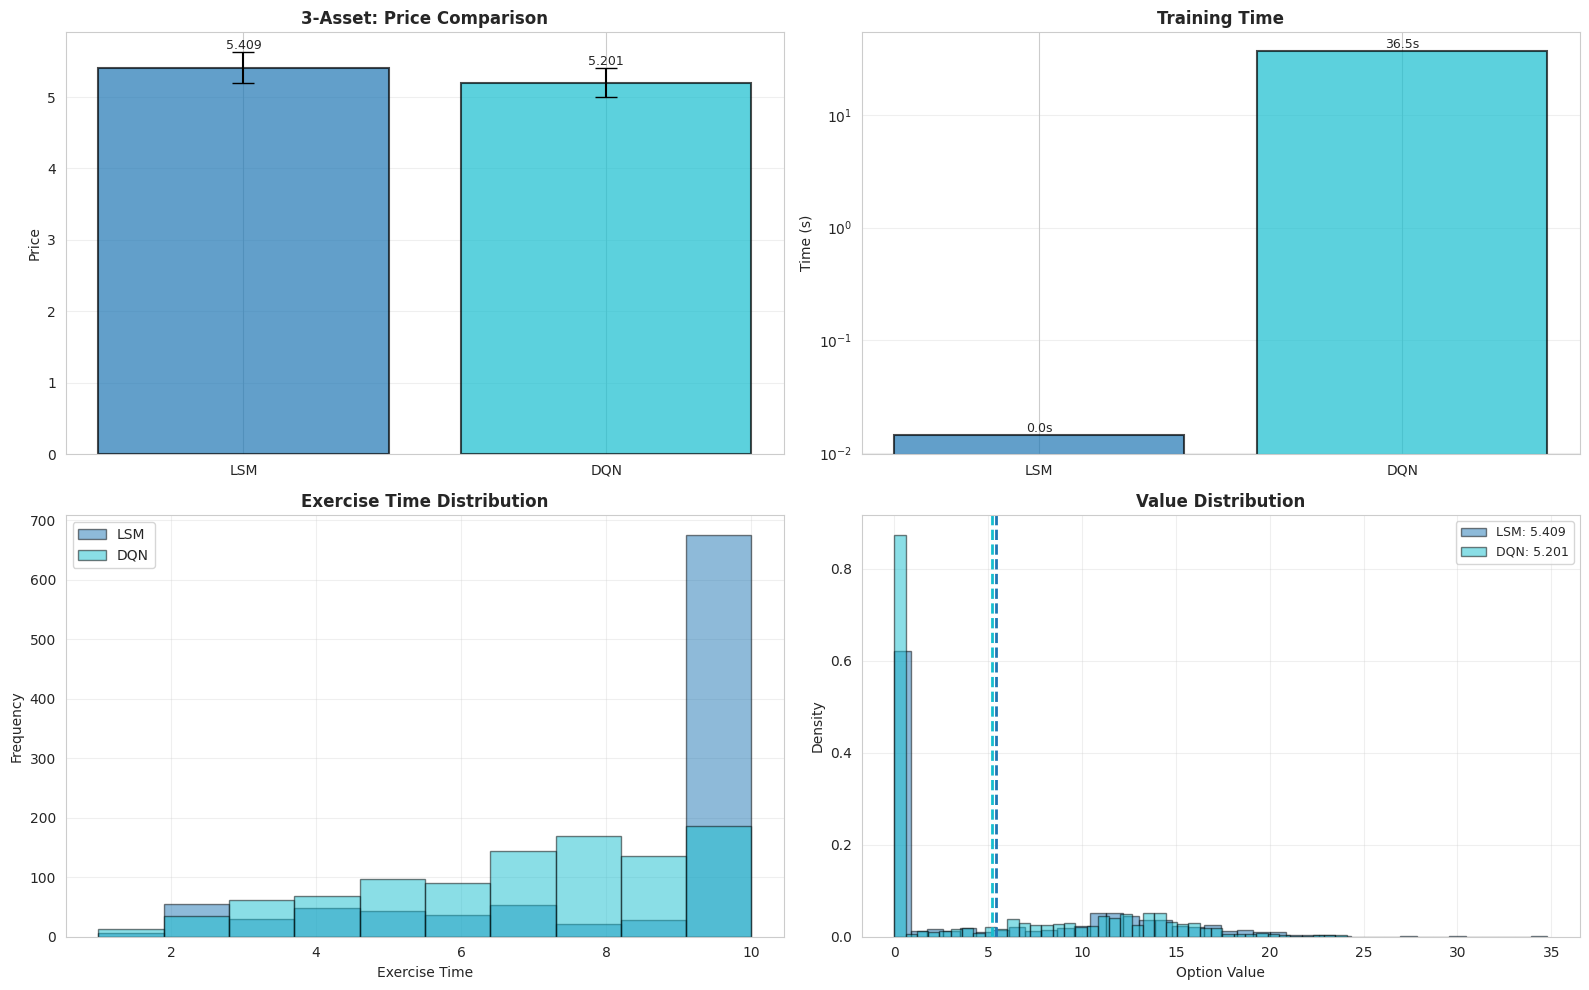

In [92]:
# Evaluate
def dqn_policy_3d(prices, t):
    norm_prices = (prices - params_3d.S0) / (params_3d.S0 * params_3d.sigma * np.sqrt(params_3d.T))
    state = np.concatenate([norm_prices, [t / params_3d.N]])
    with torch.no_grad():
        state_t = torch.FloatTensor(state).unsqueeze(0).to(dqn_3d.device)
        return dqn_3d.policy_net(state_t).argmax(dim=1).item()

lsm_vals_3d, lsm_ex_3d = evaluate_policy_on_paths(test_paths_3d, lsm_3d.get_policy_function(), params_3d)
dqn_vals_3d, dqn_ex_3d = evaluate_policy_on_paths(test_paths_3d, dqn_policy_3d, params_3d)

results_3d = [
    PolicyResult("LSM", lsm_vals_3d, lsm_ex_3d, lsm_time_3d),
    PolicyResult("DQN", dqn_vals_3d, dqn_ex_3d, dqn_time_3d, dqn_3d.episode_rewards)
]

print_results_table(results_3d)
plot_comparison(results_3d, params_3d)

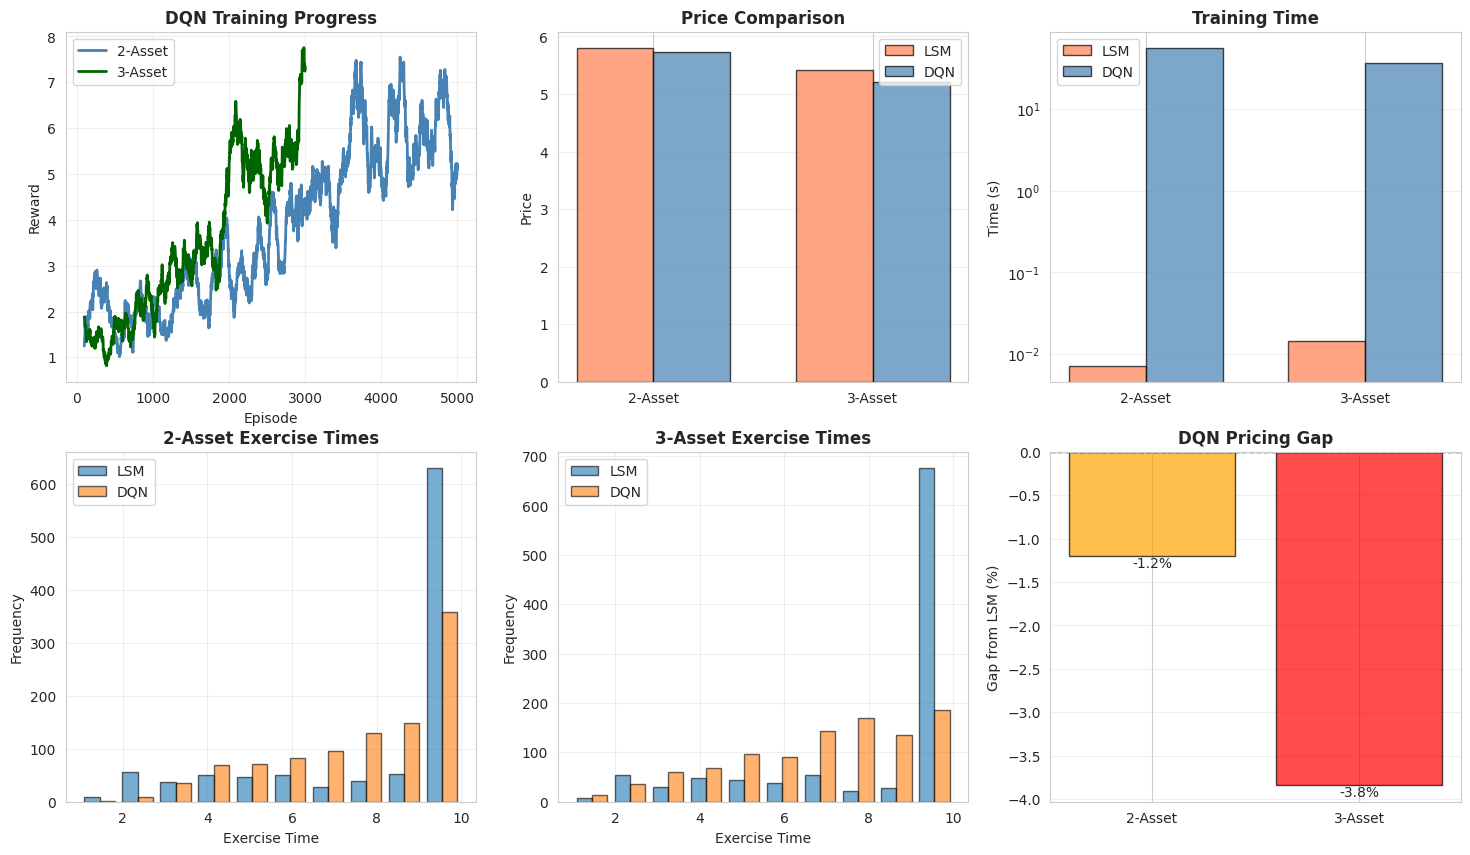

In [ ]:
# # Combined comparison plot
# fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# # Training curves
# ax = axes[0, 0]
# for rewards, label, color in [(dqn_2d.episode_rewards, '2-Asset', 'steelblue'),
#                                (dqn_3d.episode_rewards, '3-Asset', 'darkgreen')]:
#     smoothed = pd.Series(rewards).rolling(100).mean()
#     ax.plot(smoothed, label=label, linewidth=2, color=color)
# ax.set_xlabel('Episode')
# ax.set_ylabel('Reward')
# ax.set_title('DQN Training Progress', fontweight='bold')
# ax.legend()
# ax.grid(True, alpha=0.3)

# # Price comparison
# ax = axes[0, 1]
# x = np.arange(2)
# width = 0.35
# ax.bar(x - width/2, [results_2d[0].mean, results_3d[0].mean], width, 
#        label='LSM', color='coral', alpha=0.7, edgecolor='black')
# ax.bar(x + width/2, [results_2d[1].mean, results_3d[1].mean], width,
#        label='DQN', color='steelblue', alpha=0.7, edgecolor='black')
# ax.set_ylabel('Price')
# ax.set_xticks(x)
# ax.set_xticklabels(['2-Asset', '3-Asset'])
# ax.set_title('Price Comparison', fontweight='bold')
# ax.legend()
# ax.grid(True, axis='y', alpha=0.3)

# # Training time
# ax = axes[0, 2]
# ax.bar(x - width/2, [lsm_time, lsm_time_3d], width,
#        label='LSM', color='coral', alpha=0.7, edgecolor='black')
# ax.bar(x + width/2, [dqn_time, dqn_time_3d], width,
#        label='DQN', color='steelblue', alpha=0.7, edgecolor='black')
# ax.set_ylabel('Time (s)')
# ax.set_yscale('log')
# ax.set_xticks(x)
# ax.set_xticklabels(['2-Asset', '3-Asset'])
# ax.set_title('Training Time', fontweight='bold')
# ax.legend()
# ax.grid(True, axis='y', alpha=0.3)

# # 2-asset distributions
# ax = axes[1, 0]
# ax.hist([results_2d[0].exercise_times, results_2d[1].exercise_times], 
#         bins=10, label=['LSM', 'DQN'], alpha=0.6, edgecolor='black')
# ax.set_xlabel('Exercise Time')
# ax.set_ylabel('Frequency')
# ax.set_title('2-Asset Exercise Times', fontweight='bold')
# ax.legend()
# ax.grid(True, alpha=0.3)

# # 3-asset distributions
# ax = axes[1, 1]
# ax.hist([results_3d[0].exercise_times, results_3d[1].exercise_times],
#         bins=10, label=['LSM', 'DQN'], alpha=0.6, edgecolor='black')
# ax.set_xlabel('Exercise Time')
# ax.set_ylabel('Frequency')
# ax.set_title('3-Asset Exercise Times', fontweight='bold')
# ax.legend()
# ax.grid(True, alpha=0.3)

# # Gap analysis
# ax = axes[1, 2]
# gaps = [(results_2d[1].mean - results_2d[0].mean) / results_2d[0].mean * 100,
#         (results_3d[1].mean - results_3d[0].mean) / results_3d[0].mean * 100]
# colors = ['green' if g > -1 else 'orange' if g > -3 else 'red' for g in gaps]
# ax.bar(['2-Asset', '3-Asset'], gaps, color=colors, alpha=0.7, edgecolor='black')
# ax.axhline(0, color='black', linestyle='--', linewidth=1)
# ax.set_ylabel('Gap from LSM (%)')
# ax.set_title('DQN Pricing Gap', fontweight='bold')
# ax.grid(True, axis='y', alpha=0.3)
# for i, g in enumerate(gaps):
#     ax.text(i, g, f'{g:+.1f}%', ha='center', va='bottom' if g > 0 else 'top', fontsize=10)


### Experiment: 50-Asset Basket Option (Scalability Test)

In [ ]:
# 100-asset parameters - test scalability
params_100d = MultiAssetOptionParams(
    S0=np.full(100, 100.0),
    K=100.0,
    sigma=np.linspace(0.15, 0.35, 100),  # Varying volatilities
    rho=None,  # Default: identity (independent for simplicity)
    weights=np.full(100, 0.02)  # Equal weights
)
gen_100d = MultiAssetGBMPathGenerator(params_100d)

print(f"100-Asset Setup: {params_100d.n_assets} assets, state dim = {params_100d.n_assets + 1}")

N_TEST = 1000

# Generate paths
train_paths_100d = gen_100d.generate_paths(params_100d, 2000, seed=300)
test_paths_100d = gen_100d.generate_paths(params_100d, N_TEST, seed=777)

print(f"Training paths: {train_paths_100d.shape}")
print(f"Test paths: {test_paths_100d.shape}")

50-Asset Setup: 50 assets, state dim = 51
Training paths: (2000, 11, 50)
Test paths: (1000, 11, 50)


In [ ]:
# Train LSM
print("\nTraining LSM on 50 assets...")
lsm_50d = MultiAssetLSMPolicy(params_100d, 'basket')

try:
    lsm_time_50d = lsm_50d.train(train_paths_50d)
    print(f"LSM training: {lsm_time_50d:.2f}s")
    lsm_50d_success = True
except Exception as e:
    print(f"LSM failed: {e}")
    print("Note: LSM basis grows exponentially - 50 assets = 1 + 50 + 50 + 1225 = 1276 basis functions")
    lsm_50d_success = False


Training LSM on 50 assets...
LSM training: 0.56s


In [ ]:
# Train DQN - should handle 100D naturally
print("\nTraining DQN on 100 assets...")
env_100d = MultiAssetBermudanPutEnv(params_100d, gen_100d, 'basket', seed=44)
wrapped_100d = MultiAssetEnvWrapper(env_100d)

dqn_100d = DQNAgent(
    state_dim=101,  # 100 assets + time
    action_dim=2,
    hidden_dims=[128, 128, 64],  # Deeper network
    learning_rate=0.001,
    gamma=1.0,
    epsilon_schedule=linear_decay_schedule(1.0, 0.01, 1400),
    batch_size=64,
    target_update_freq=50,
    seed=44
)

start = time.time()
dqn_100d.train(wrapped_100d, n_episodes=2000, verbose=1, use_tqdm=True)
dqn_time_50d = time.time() - start

print(f"\nDQN training: {dqn_time_50d:.2f}s")


Training DQN on 50 assets...


Training DQN:   0%|          | 0/2000 [00:00<?, ?it/s]


DQN training: 38.98s



Method  Price Std Error Train Time (s) Avg Ex. Time
   LSM 0.3391    0.0212           0.56         7.78
   DQN 0.3605    0.0216          38.98         6.00
DQN vs LSM: +0.0214 (+6.30%), 0.71 std devs


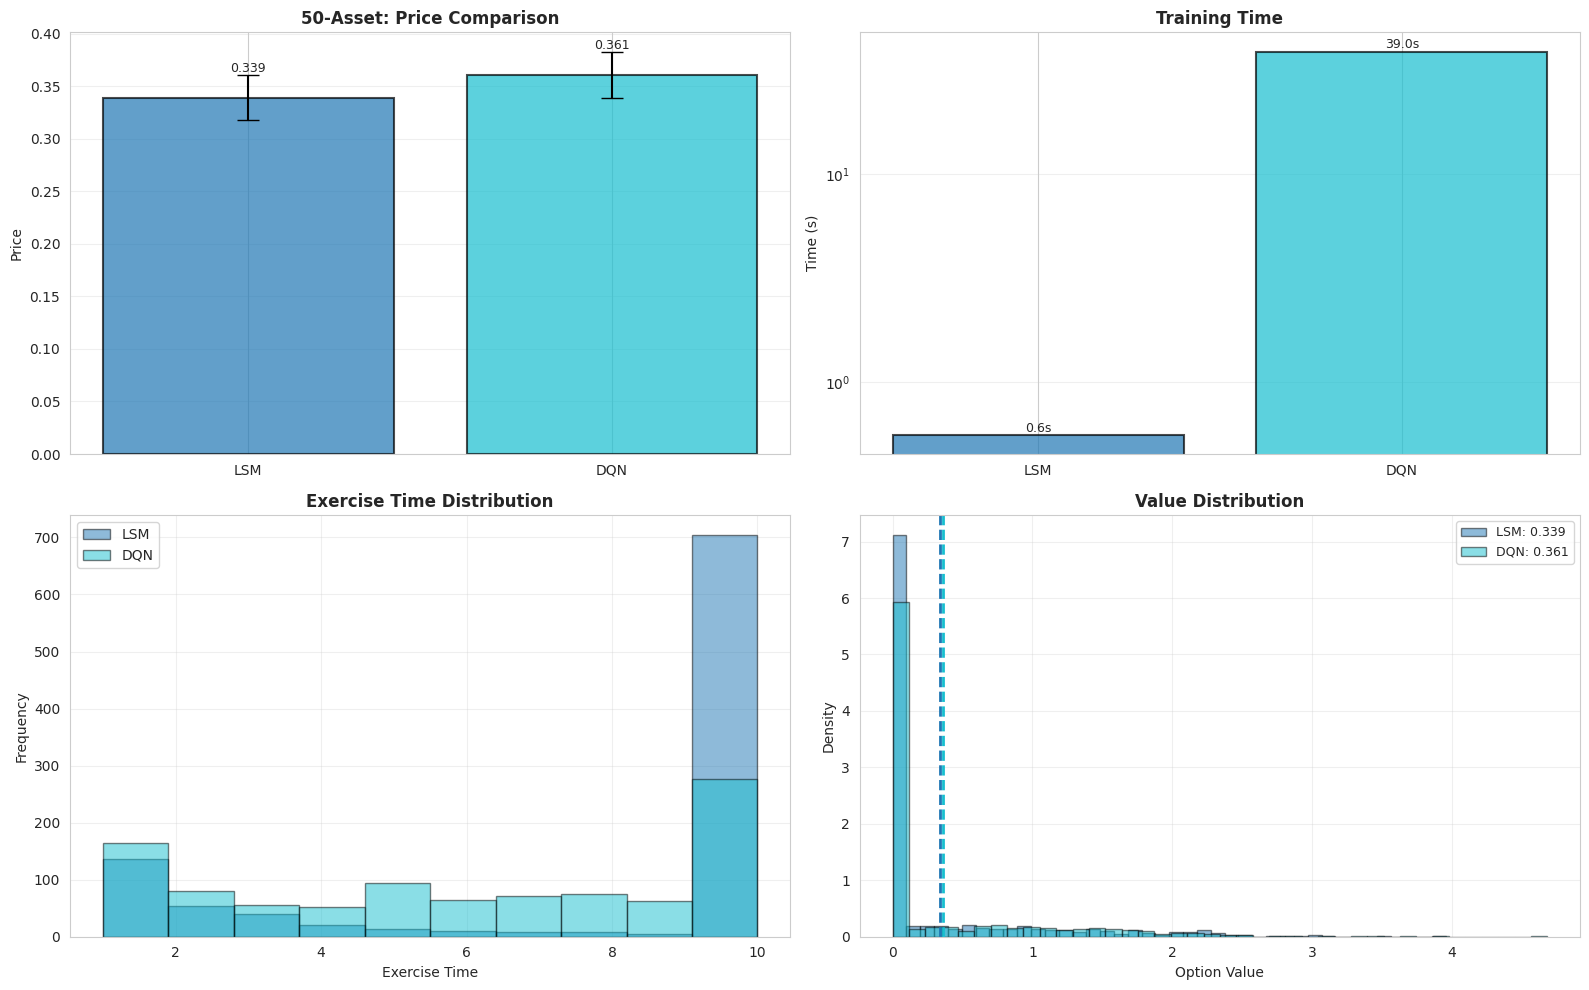

In [ ]:
# Evaluate
import torch


def dqn_policy_100d(prices, t):
    norm_prices = (prices - params_100d.S0) / (params_100d.S0 * params_100d.sigma * np.sqrt(params_100d.T))
    state = np.concatenate([norm_prices, [t / params_100d.N]])
    with torch.no_grad():
        state_t = torch.FloatTensor(state).unsqueeze(0).to(dqn_100d.device)
        return dqn_100d.policy_net(state_t).argmax(dim=1).item()

dqn_vals_100d, dqn_ex_100d = evaluate_policy_on_paths(test_paths_100d, dqn_policy_100d, params_100d)

results_100d = [PolicyResult("DQN", dqn_vals_100d, dqn_ex_100d, dqn_time_100d, dqn_100d.episode_rewards)]

if lsm_50d_success:
    lsm_vals_100d, lsm_ex_100d = evaluate_policy_on_paths(test_paths_100d, lsm_100d.get_policy_function(), params_100d)
    results_100d.insert(0, PolicyResult("LSM", lsm_vals_100d, lsm_ex_100d, lsm_time_100d))

print_results_table(results_100d)
plot_comparison(results_100d, params_100d)